# Setup

## Imports

In [1]:
import numpy as np
import pandas as pd

from rlbench.action_modes.action_mode import MoveArmThenGripper
from rlbench.action_modes.arm_action_modes import JointVelocity
from rlbench.action_modes.gripper_action_modes import Discrete

from rlbench.environment import Environment
from rlbench.task_environment import TaskEnvironment
from rlbench.observation_config import ObservationConfig, CameraConfig


from pyrep.const import RenderMode
from pyrep.objects import Object

import numpy as np
import torch
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from lib.cam_type import CamType
from lib.agent import Agent
from lib.policy_type import PolicyType



from seed import set_seed
from lib.utils import get_task_name
from task_utils import run_reach_task, run_grasp_with_agent

from itertools import product

set_seed()


In [2]:
## Vision Experiments - Grasp
from rlbench.tasks.vision_static import VisionStatic as Vision_Static

## Environment Launch


In [3]:
live_demos = True
DATASET = '' if live_demos else 'PATH/TO/YOUR/DATASET'

obs_config = ObservationConfig()
obs_config.set_all(True) ## important to get the data from the joints etc
cam_config = CameraConfig(rgb=True, depth=True, mask=False, point_cloud=False,
                              render_mode=RenderMode.OPENGL,
                    image_size=(64, 64))
nocam_config = CameraConfig(rgb=False, depth=False, mask=False,
                          render_mode=RenderMode.OPENGL)

## active cameras:
obs_config.right_shoulder_camera = cam_config
obs_config.left_shoulder_camera = cam_config
obs_config.wrist_camera = cam_config


obs_config.overhead_camera = nocam_config
obs_config.front_camera = nocam_config


action_mode = MoveArmThenGripper(
    arm_action_mode=JointVelocity(), gripper_action_mode=Discrete())

env = Environment(
    action_mode, DATASET, obs_config, False)
env.launch()


## Helper Functions to be used later


# Shutdown


In [4]:
env.shutdown()

[CoppeliaSim:loadinfo]   done.


# Grasping Task - Camera Experiments

Here I am investigating the use of multiple cameras aiding a more complex task like a grasping task


## (Static) Grasping with Single Camera
Following form earlier, I want to try each of the cameras I have with this task to see which performs better per static cube and a single demo.

In [18]:
cam_types = [
  CamType.WRIST, ## TODO: wrist seems to perform better with longer epispdes do a run with that
  CamType.LEFT_SHOULDER,
  CamType.RIGHT_SHOULDER,
]

task = Vision_Static
## configure the task, so that it is always the same per test here
task_env = env.get_task(task, scale = 1, wrist_cam_distance = 0.5)

training_params = {
  "epochs": 1000,
  "minibatch_size": 64,
  "lr": 1e-3,
  "shuffle_obs_in_demo": False,
  "shuffle_data": False,
  # "lock_loader_seed": 42 ## TEST: test this later not sure
  # "lambda_grasp_loss": 20 ## 1 by default
}

task_params = {
  "scale" : 1.0, 
  "wrist_cam_distance": 0.5
}

repeats = 20

In [9]:
demos = task_env.get_demos(1, live_demos = True)


[vision_static] scale: 1 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)


In [17]:
df = pd.DataFrame(columns=[
  "task_name", "cam_type", "demo_count", "max_eplen",
  "is_success", "min_distance", "final_distance",
  "gripper_image_paths"
  
], index = range(repeats * len(cam_types))) ## 30?

Running Vision_Static with wrist and 1 demo, repeat: 0
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 219.00it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May11_16-35.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist and 1 demo, repeat: 1
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 222.84it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-wrist--_May11_16-35.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with wrist and 1 demo, repeat: 2
[simple_policy] - Policy] Using wrist as camera type
2- Using given demos for task: Vision_Static
Camera: wrist
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



...

Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-r_shoulder--_May11_16-41.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with r_shoulder and 1 demo, repeat: 18
[simple_policy] - Policy] Using r_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: r_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 213.83it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-r_shoulder--_May11_16-41.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)
Running Vision_Static with r_shoulder and 1 demo, repeat: 19
[simple_policy] - Policy] Using r_shoulder as camera type
2- Using given demos for task: Vision_Static
Camera: r_shoulder
Training Params: 
	epochs = 1000, 
	minibatch_size = 64, 
	lr = 0.001, 
	model_path = None, 
	shuffle_data = False,
	shuffle_obs_in_demo = False,
	random loader 
	cuda



100%|██████████| 1000/1000 [00:04<00:00, 217.33it/s]


Done Training Policy on 1 Demos
Saved Model under './all-models/task-Vision_Static-demo-1-cam-r_shoulder--_May11_16-41.pth'
[vision_static] scale: 1.0 (picked at creation)
[vision_static] dist: 0.5 (picked at creation)


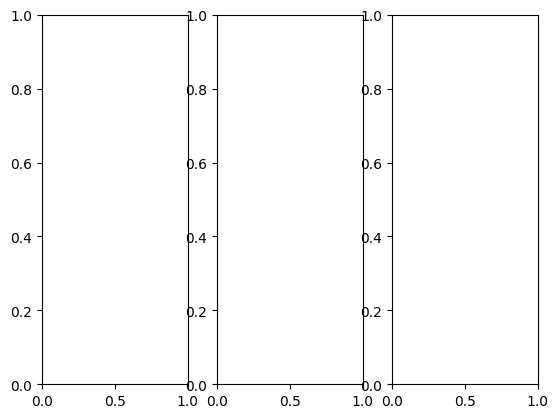

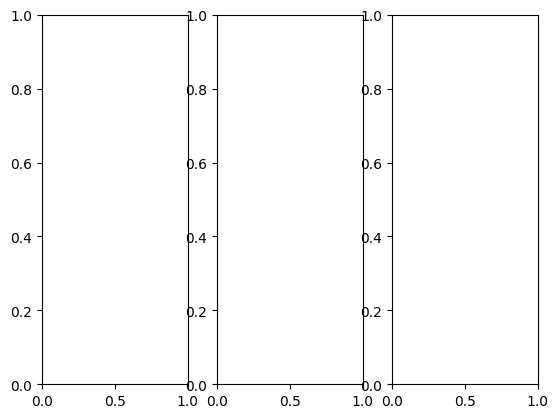

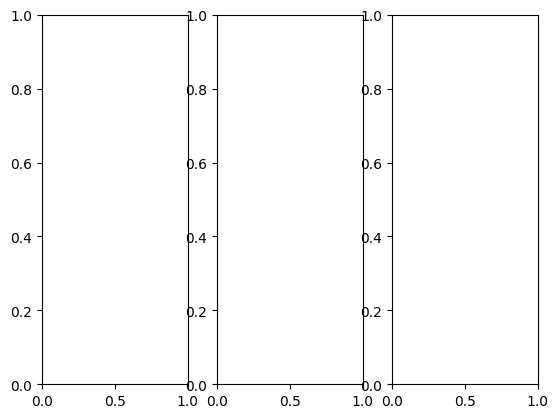

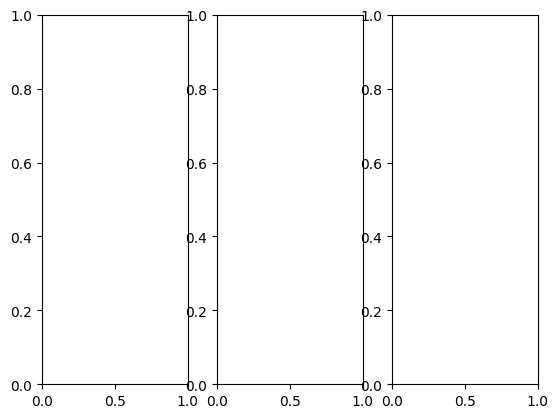

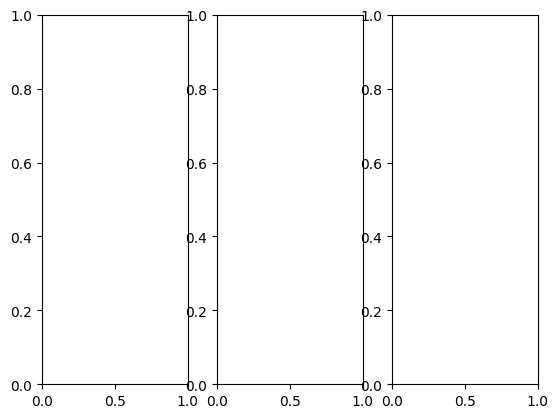

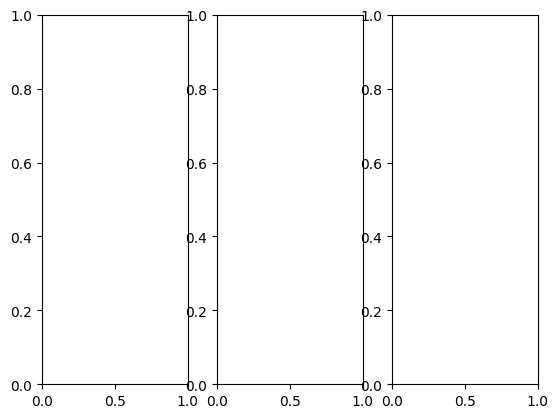

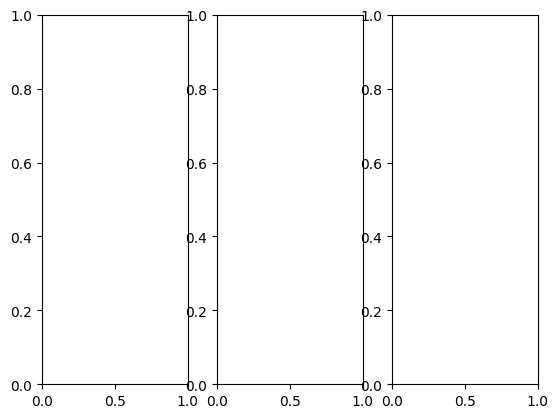

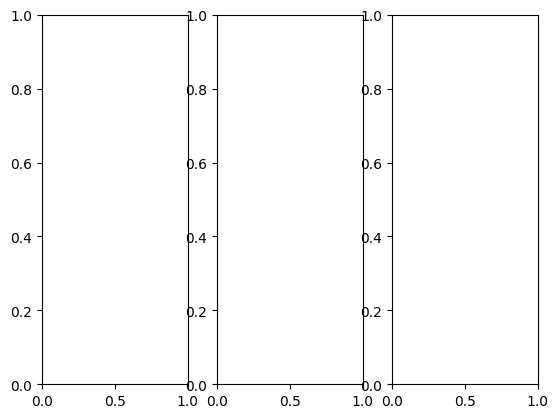

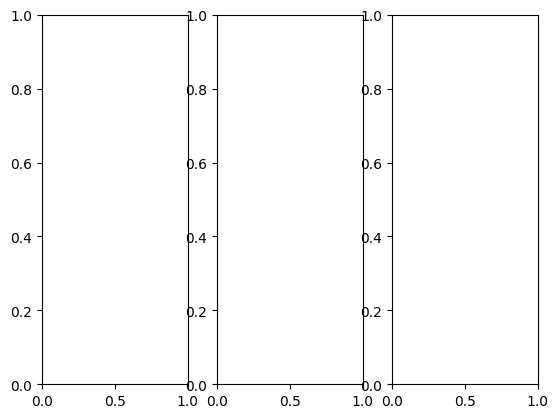

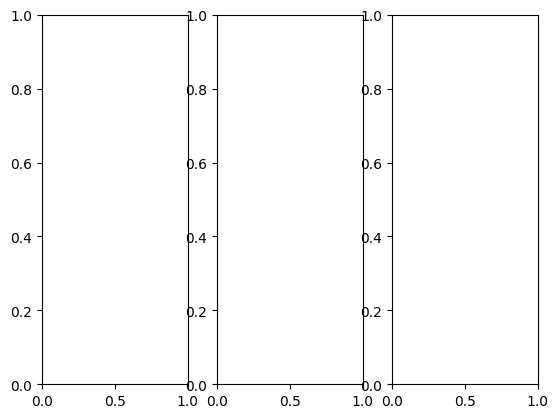

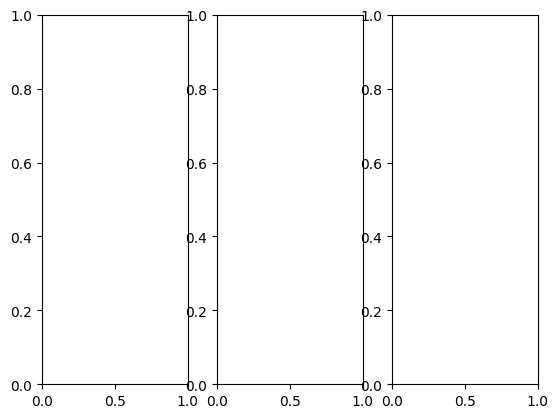

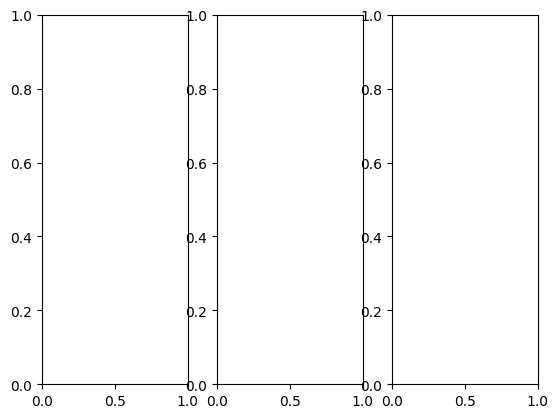

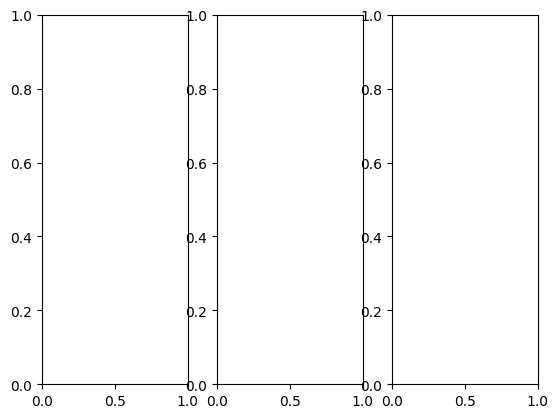

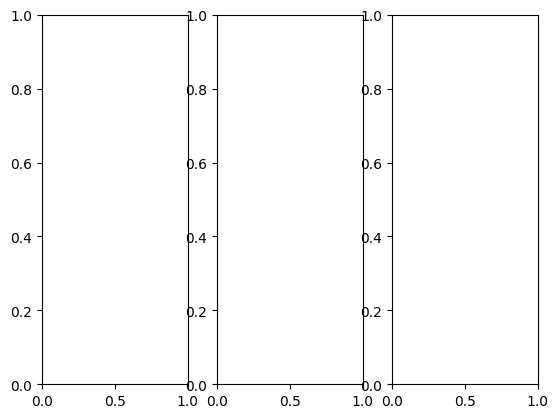

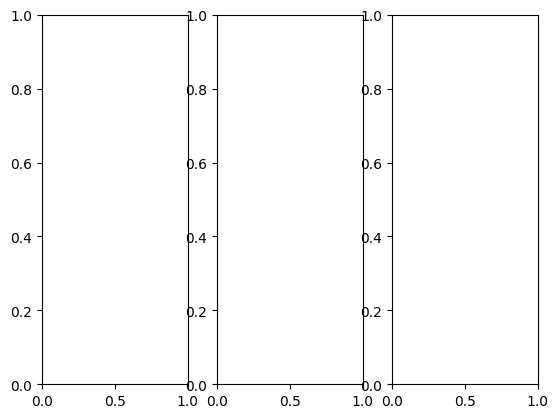

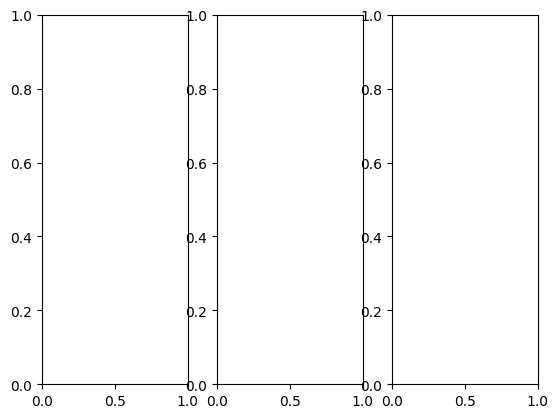

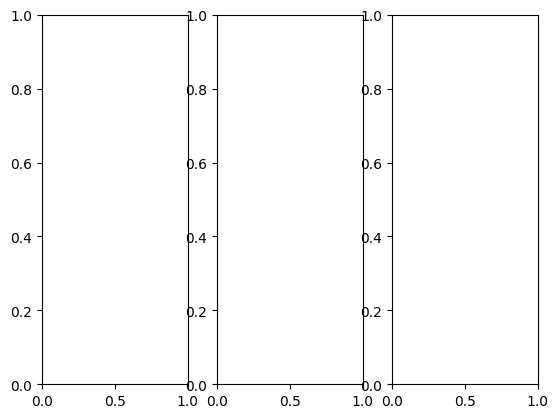

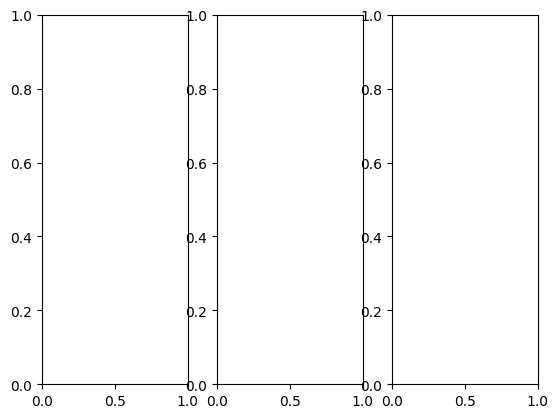

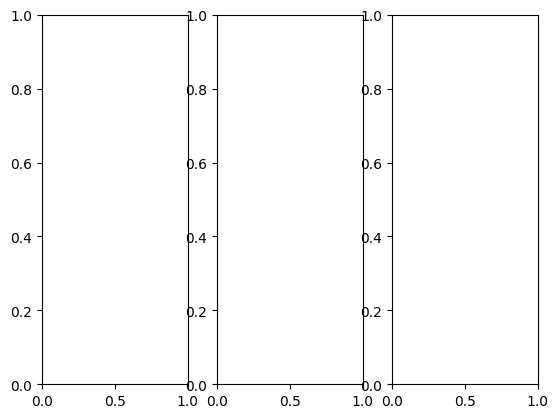

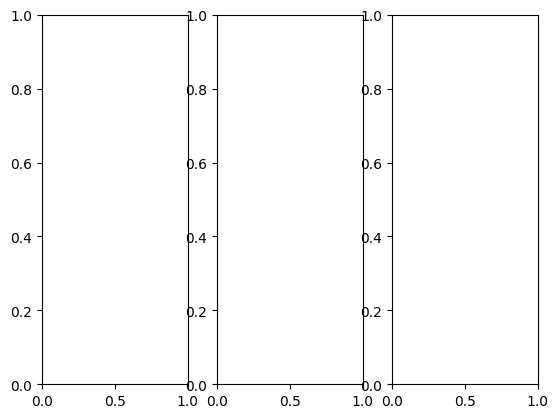

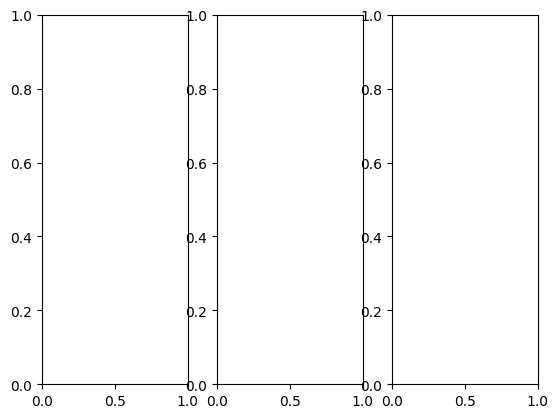

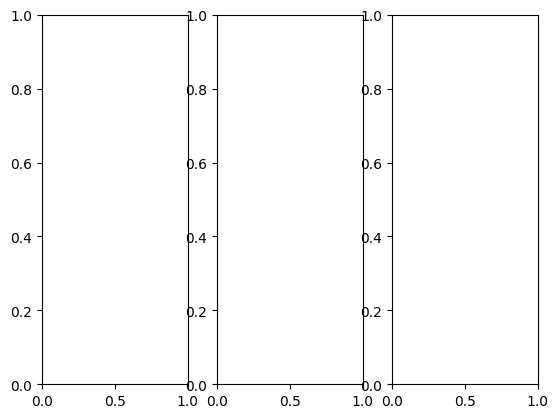

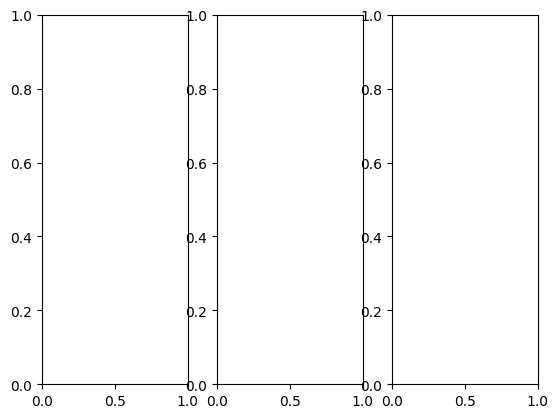

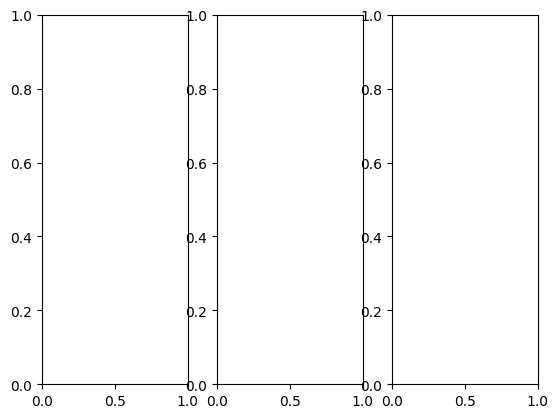

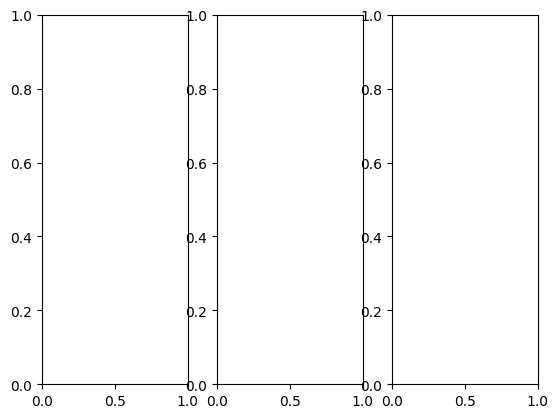

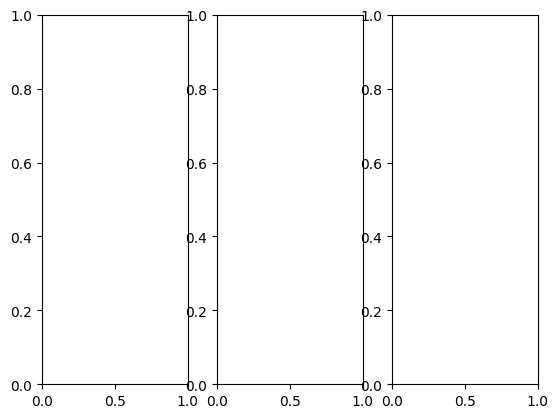

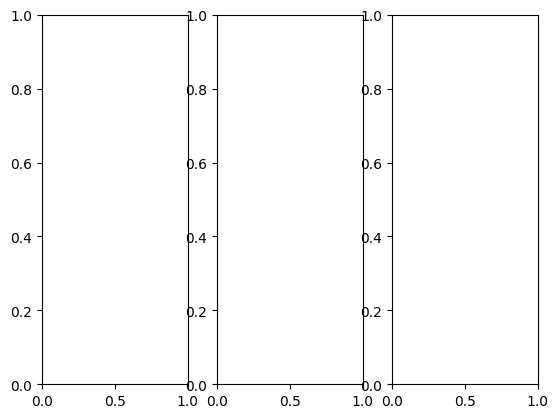

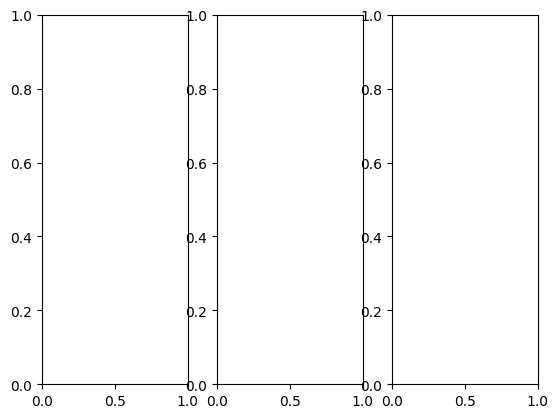

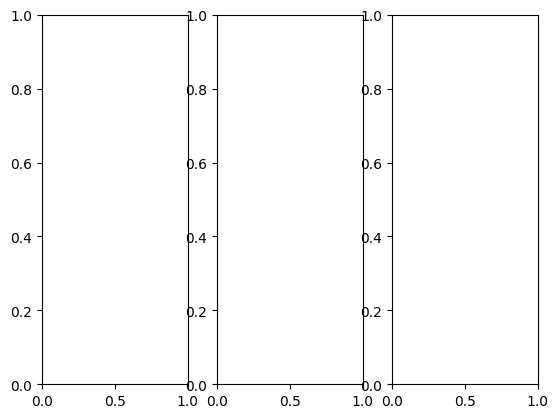

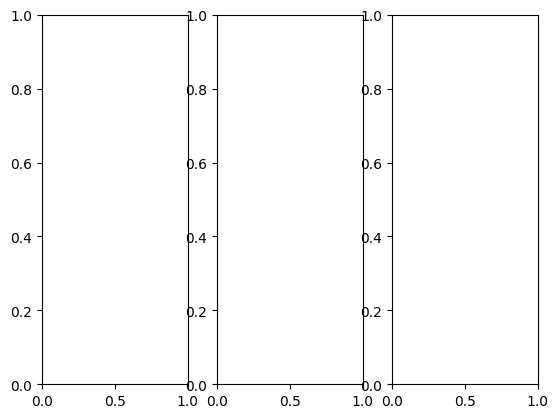

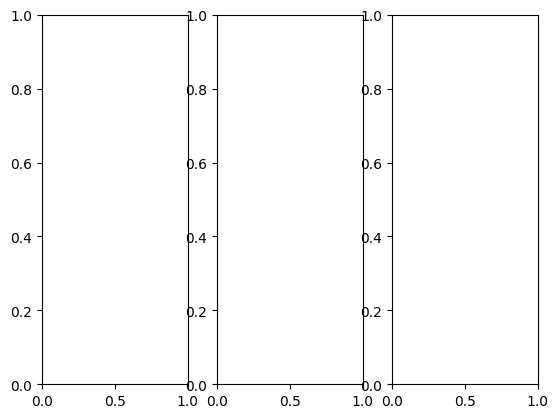

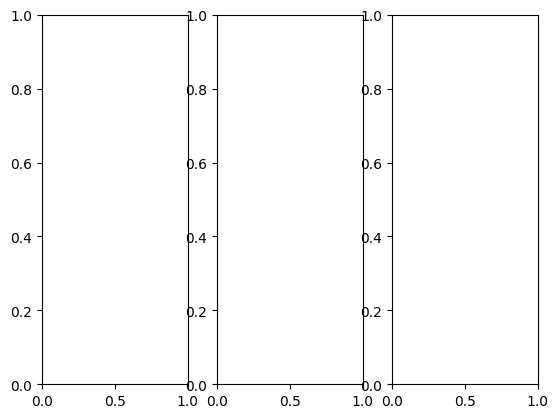

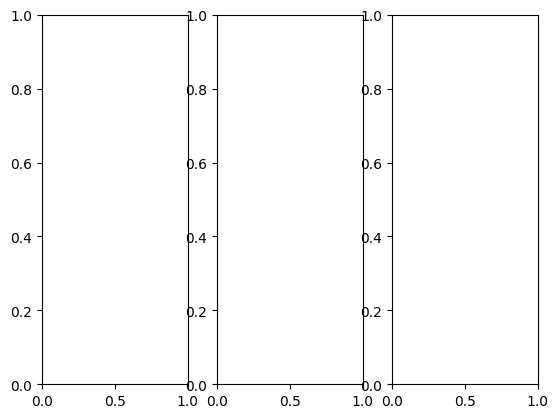

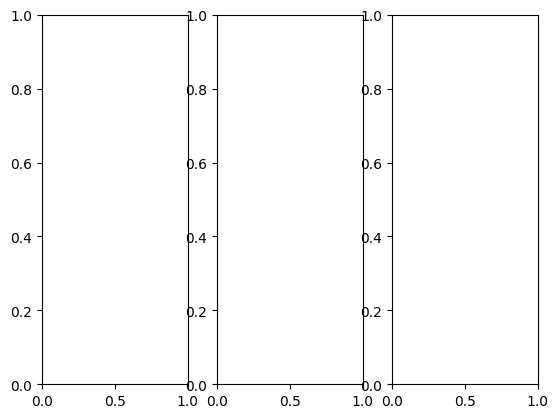

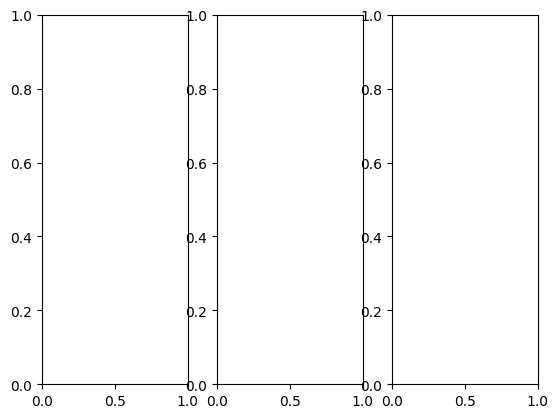

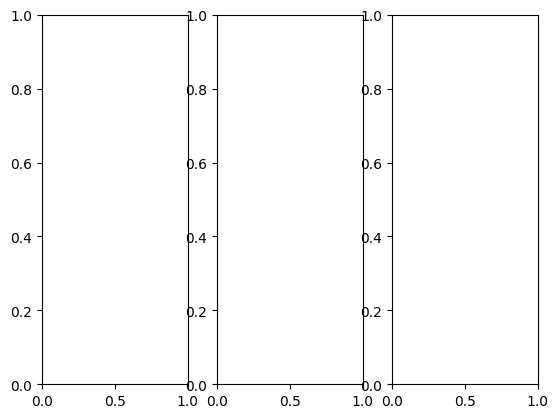

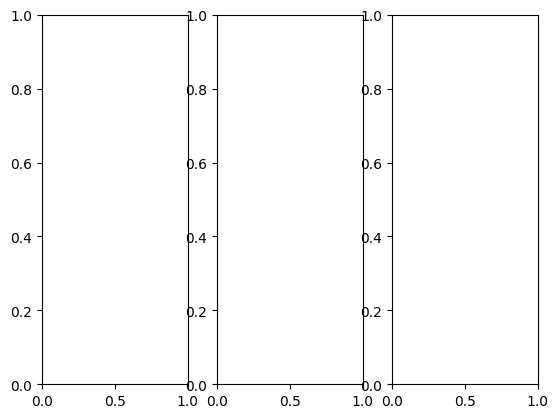

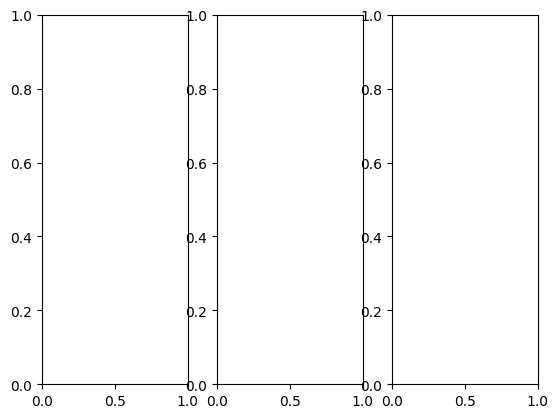

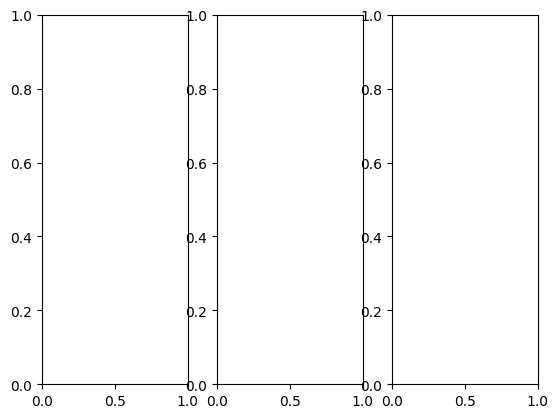

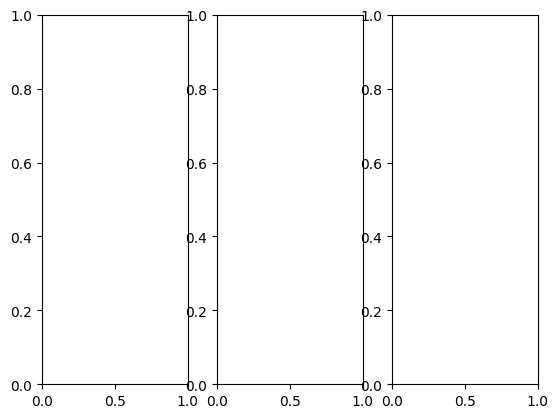

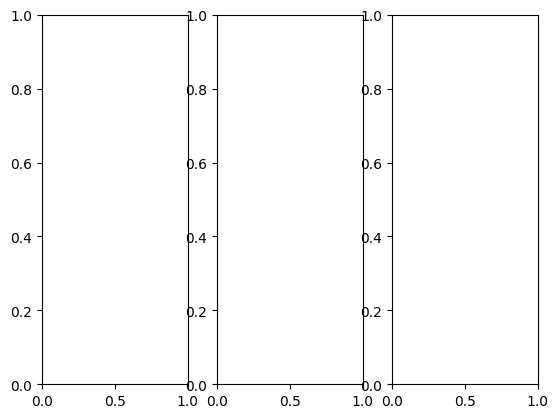

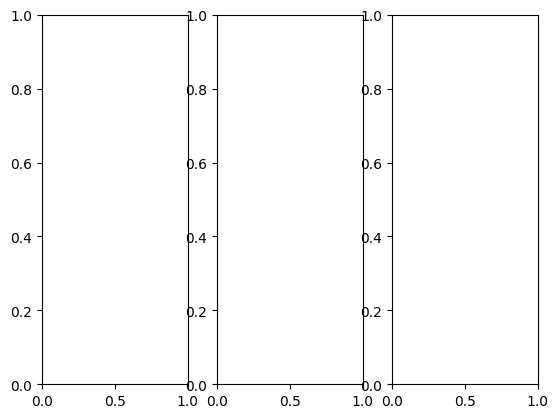

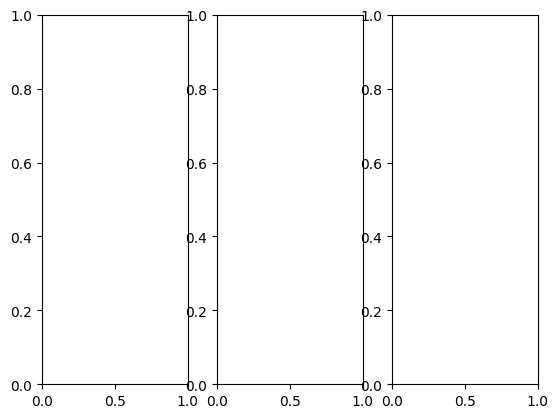

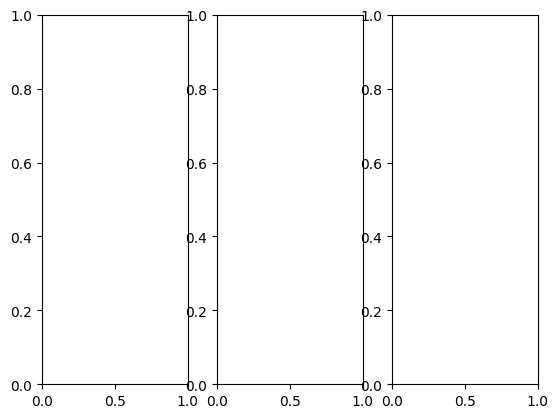

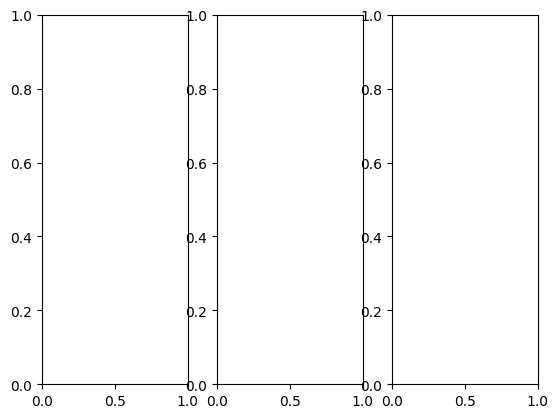

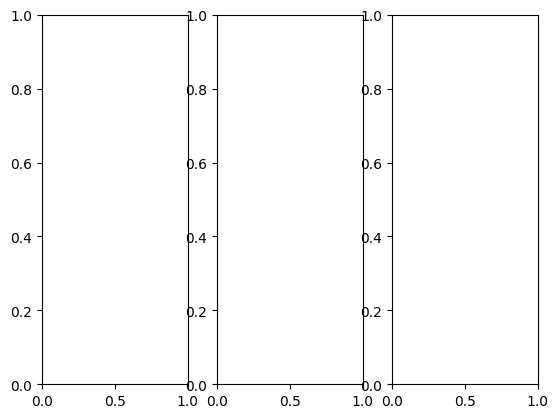

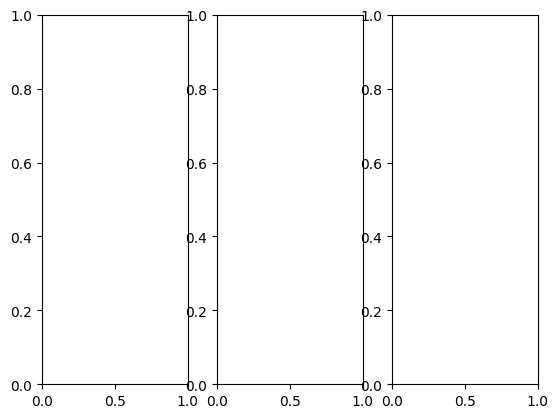

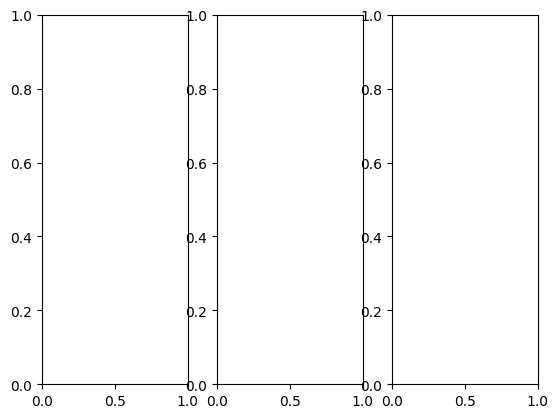

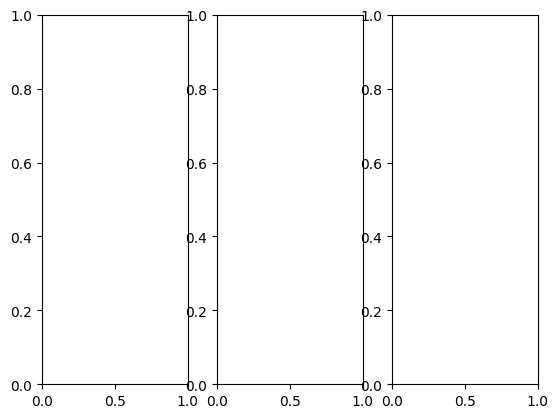

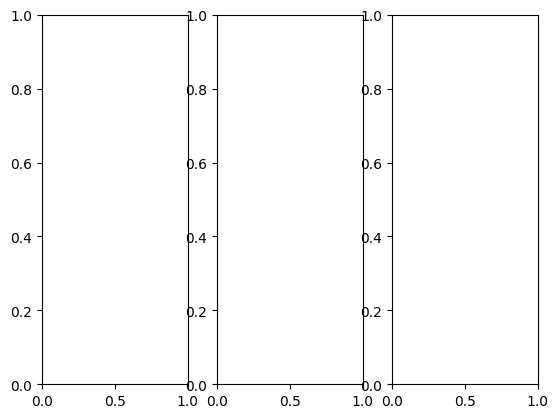

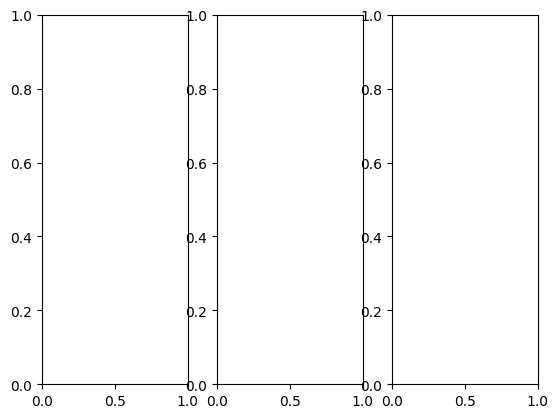

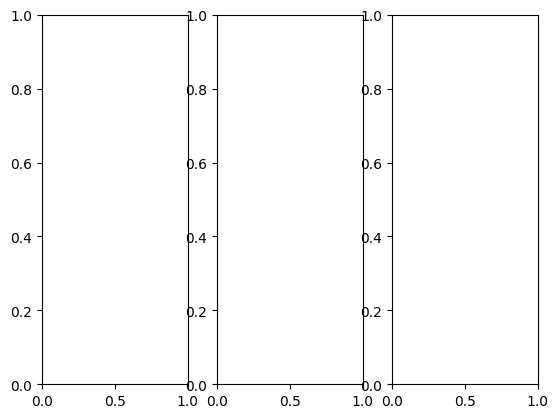

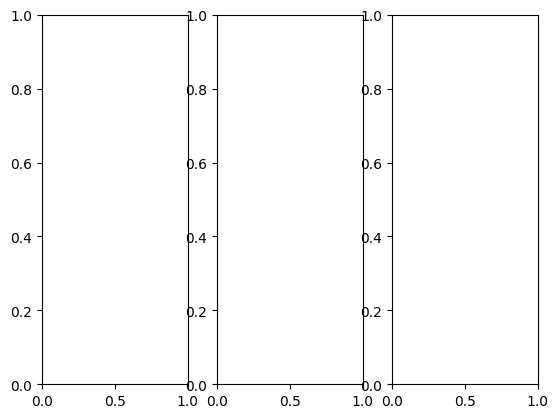

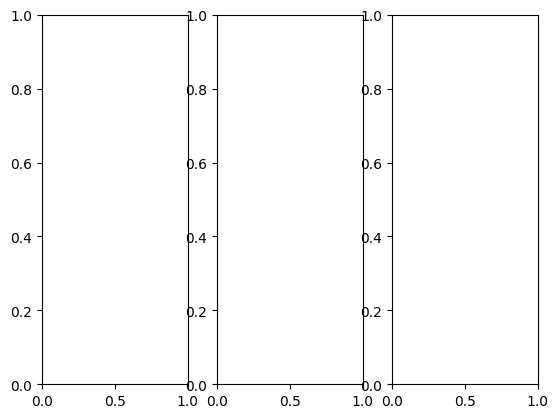

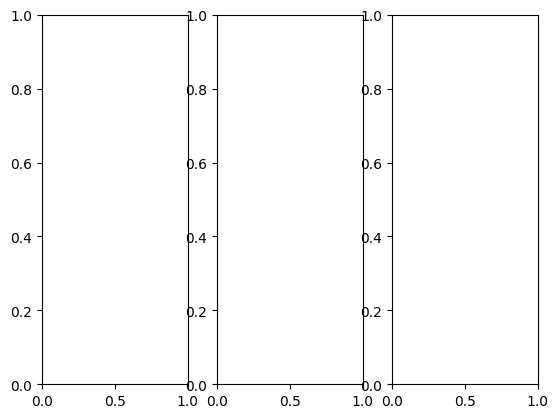

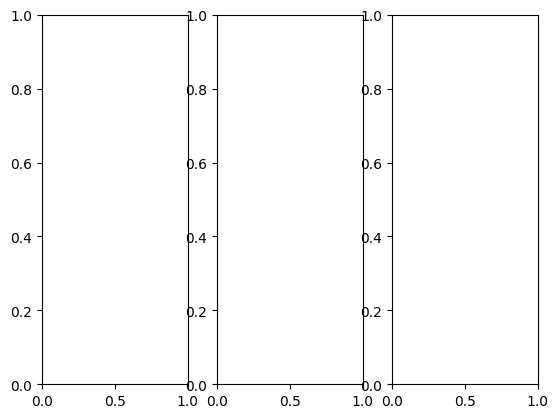

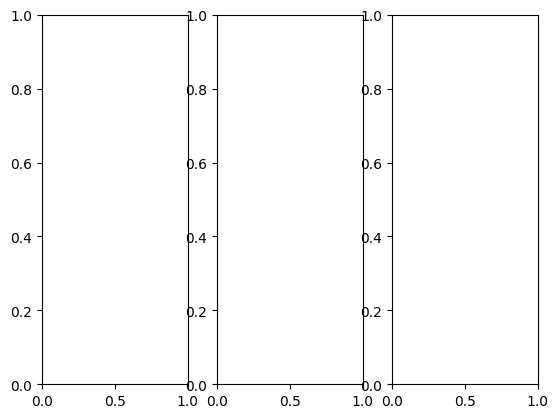

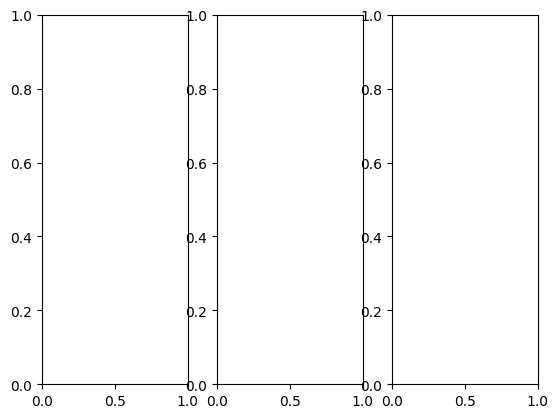

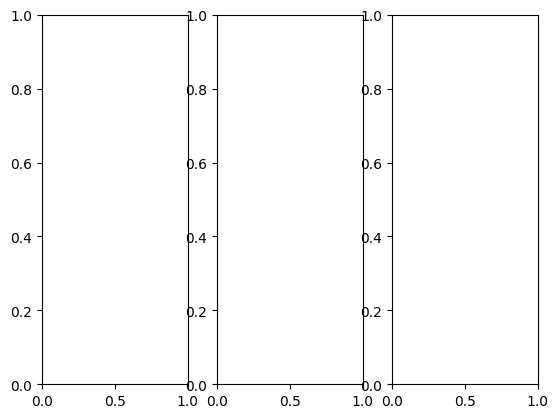

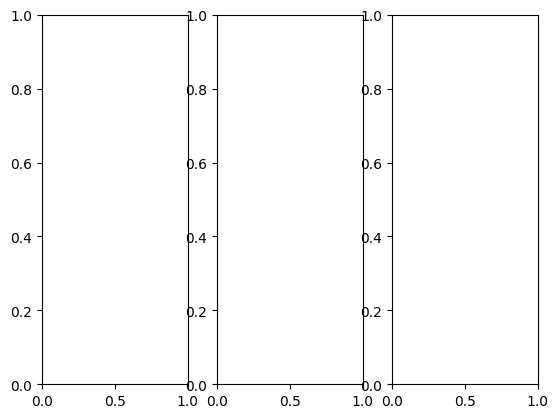

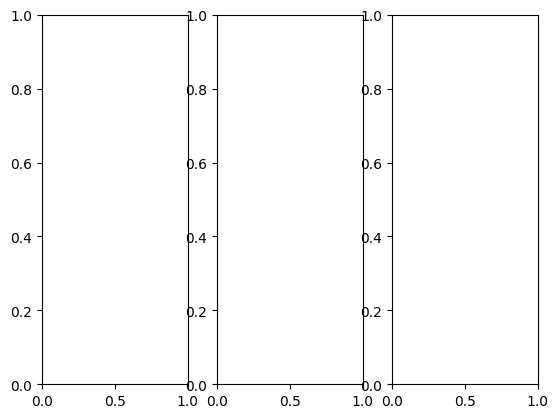

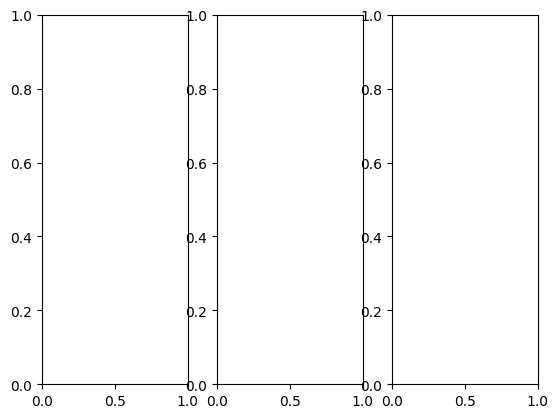

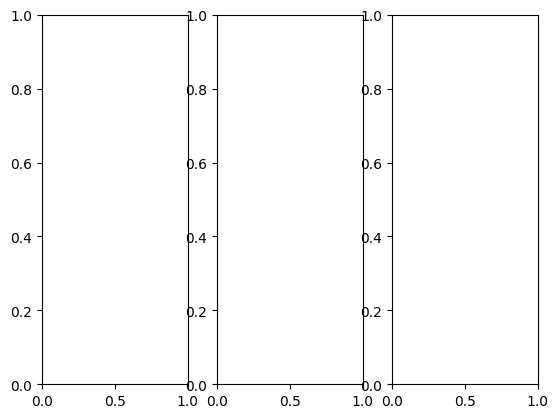

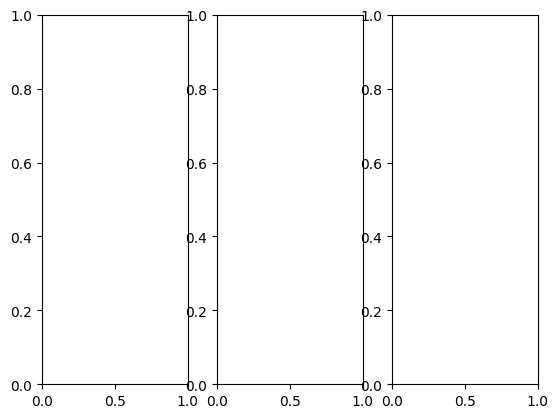

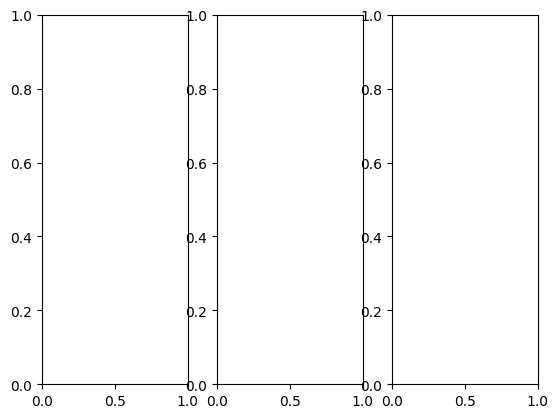

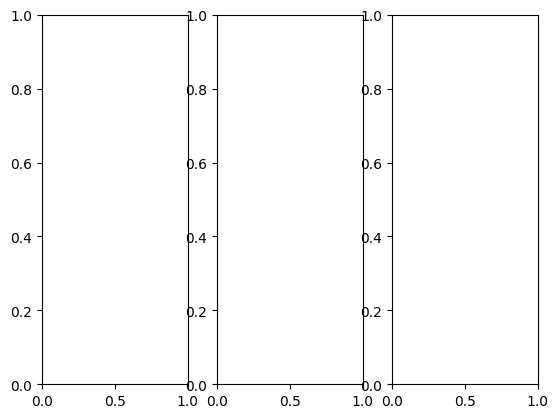

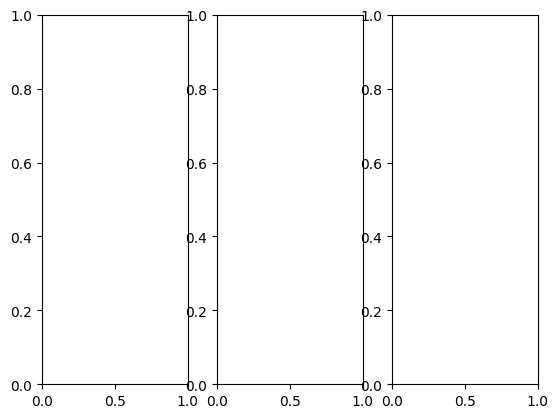

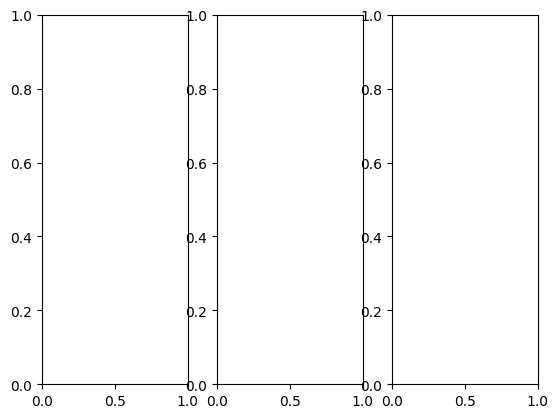

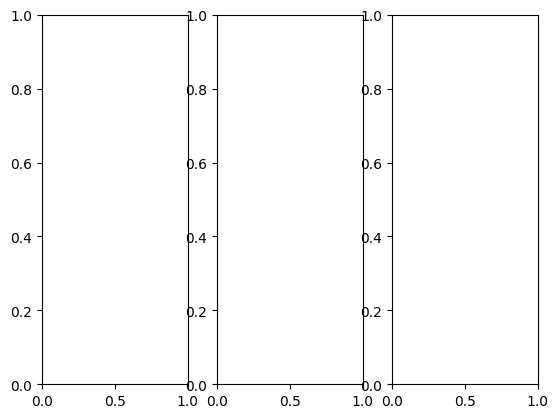

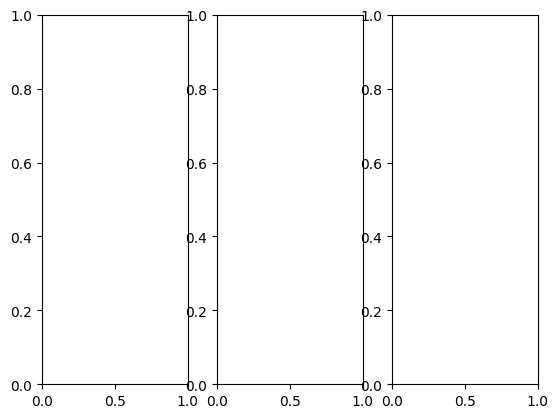

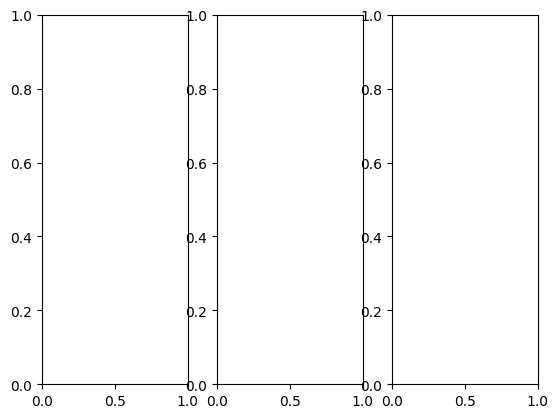

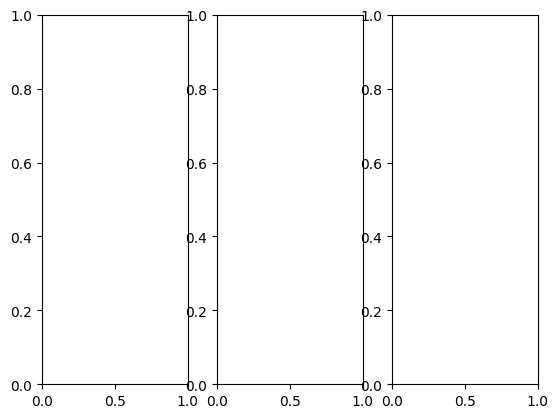

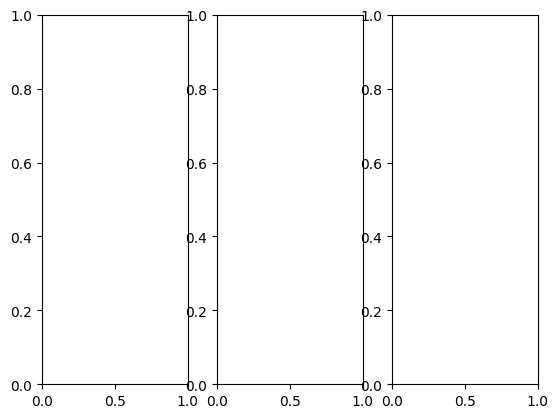

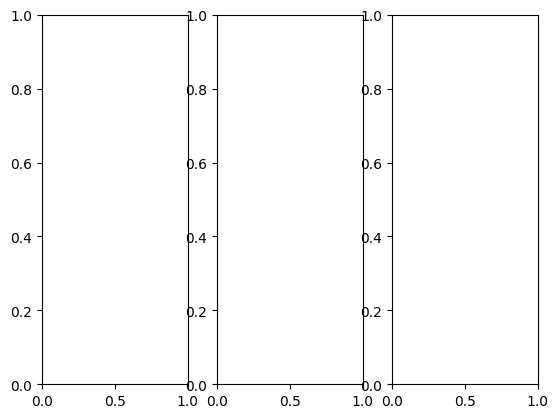

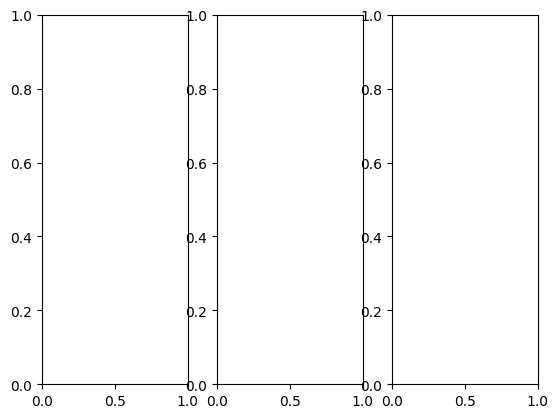

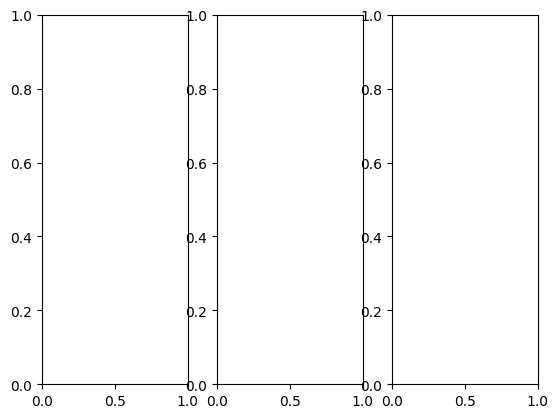

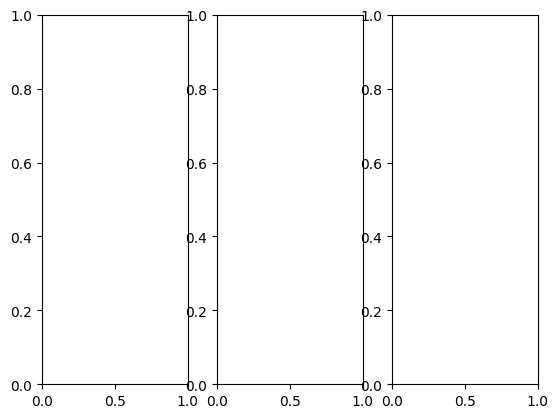

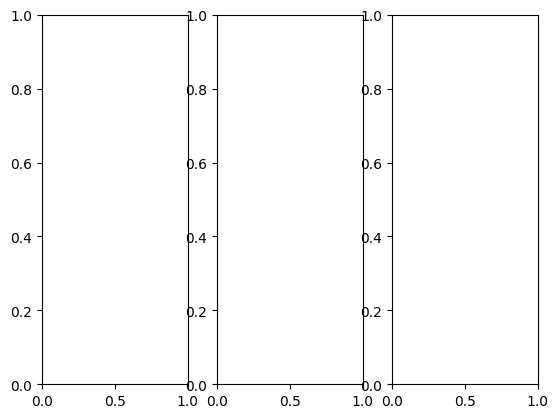

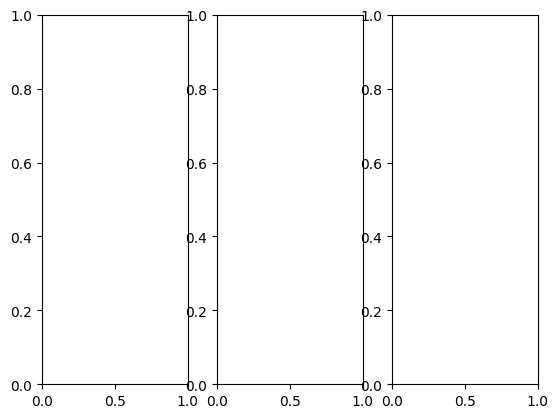

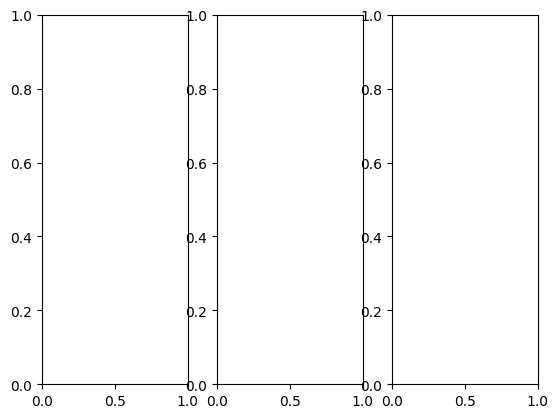

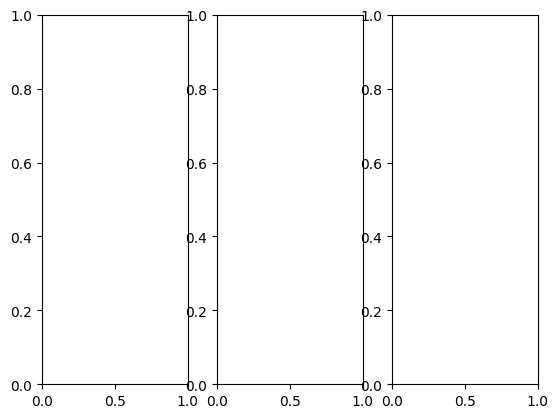

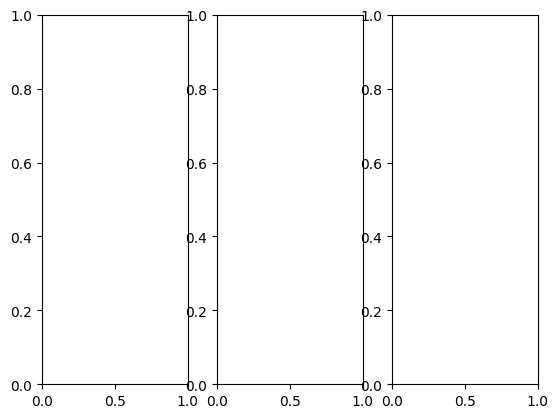

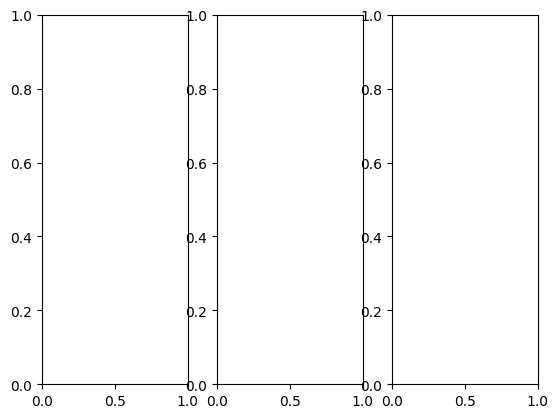

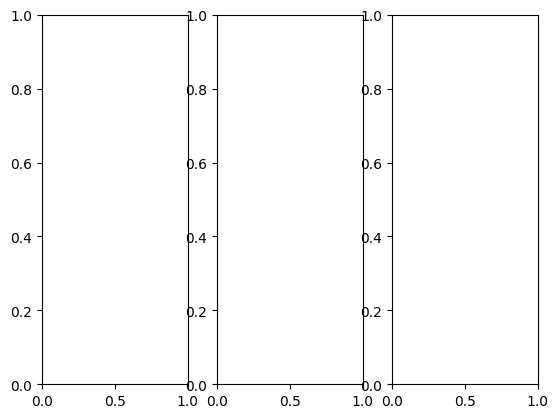

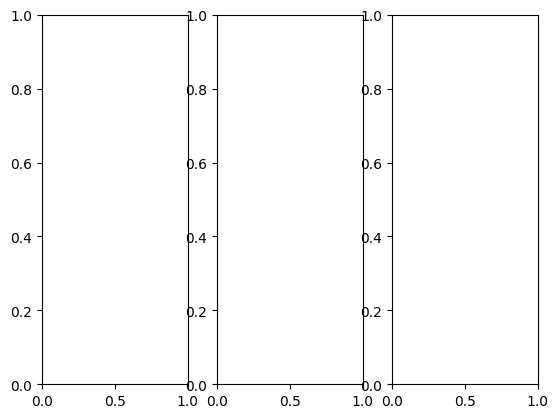

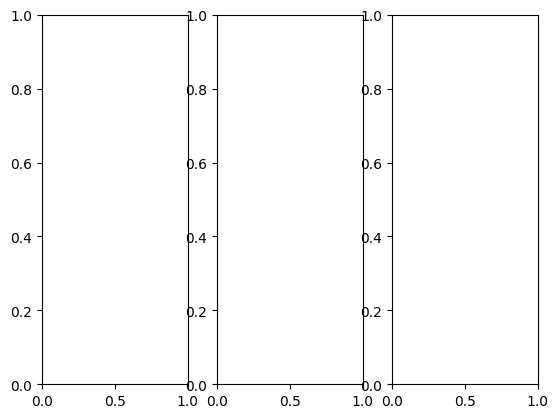

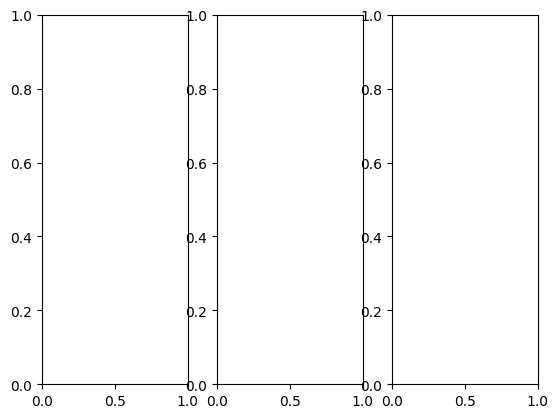

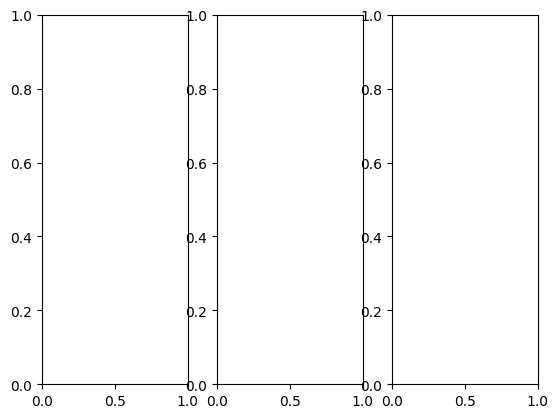

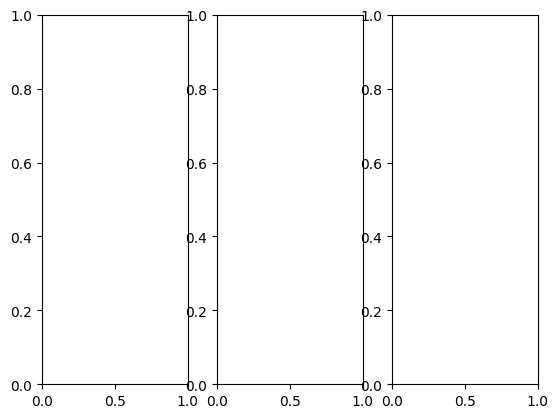

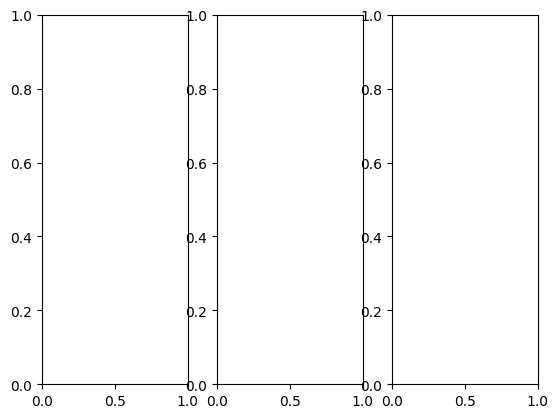

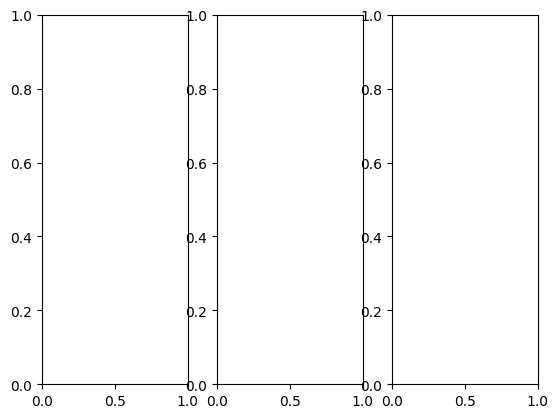

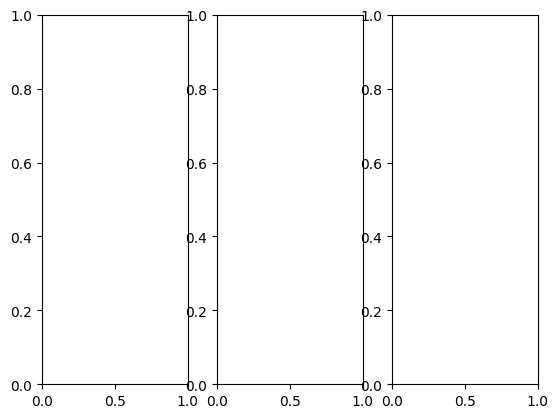

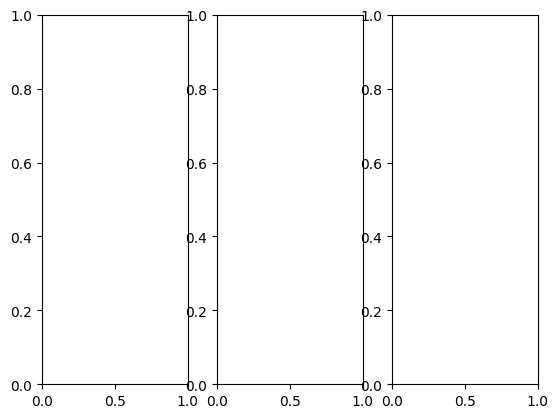

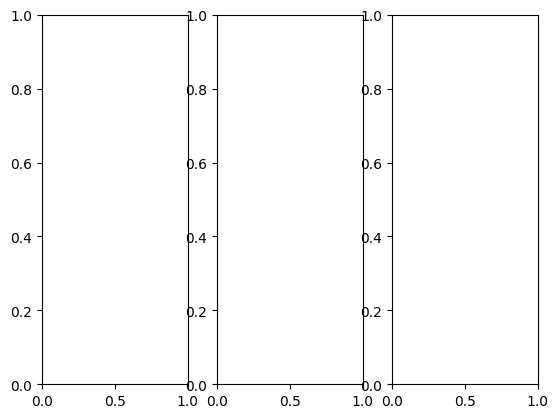

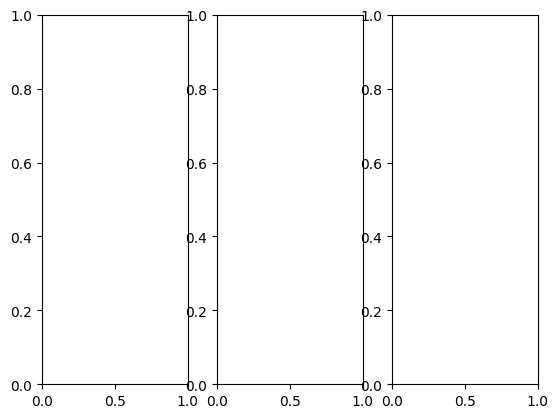

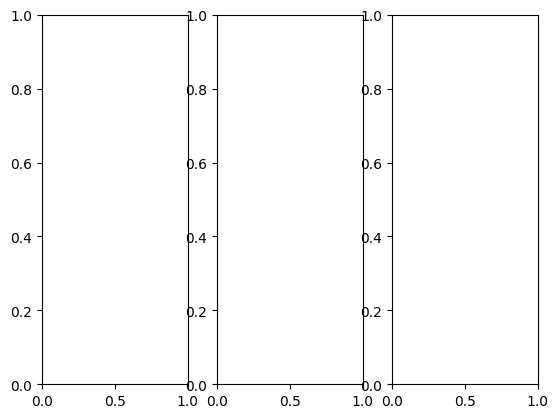

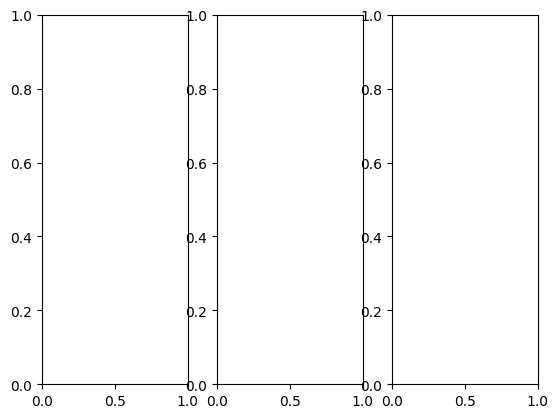

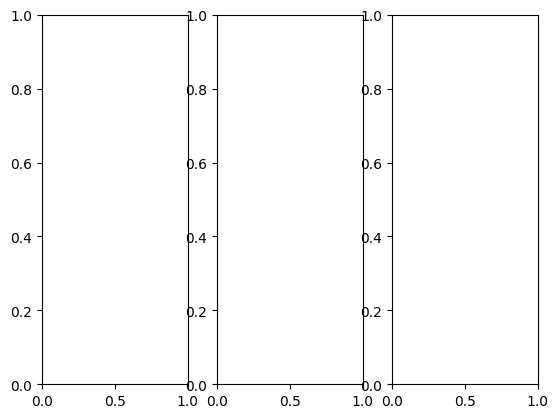

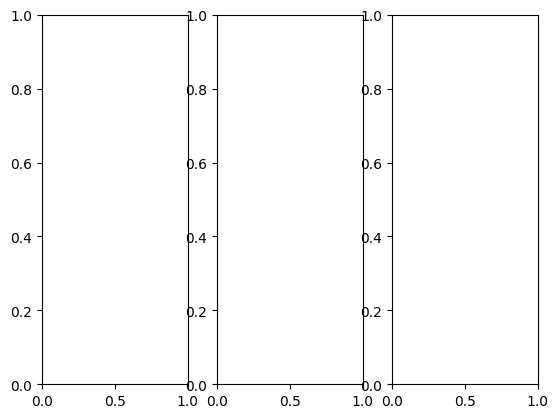

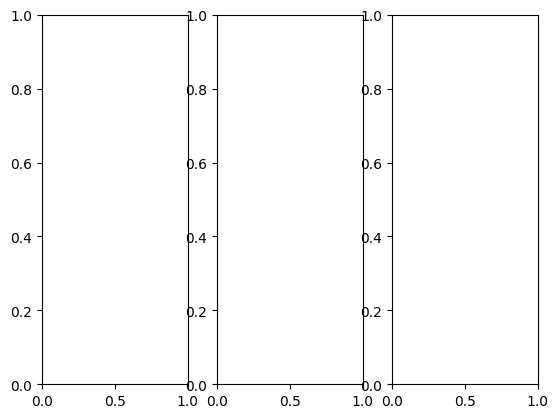

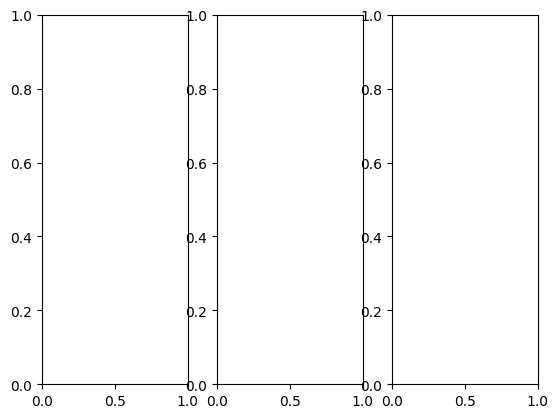

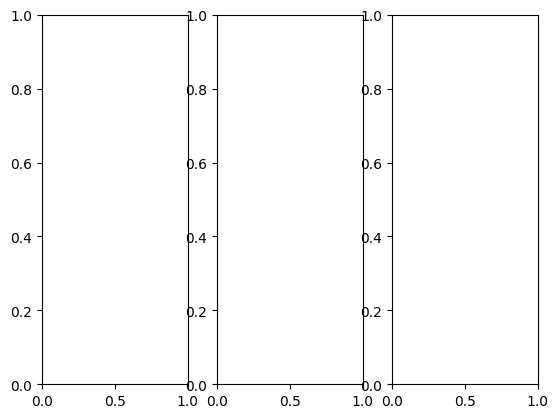

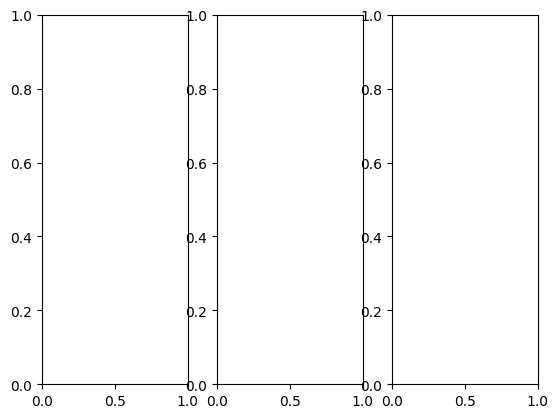

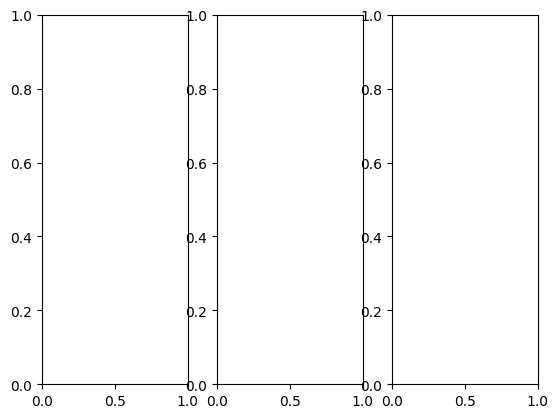

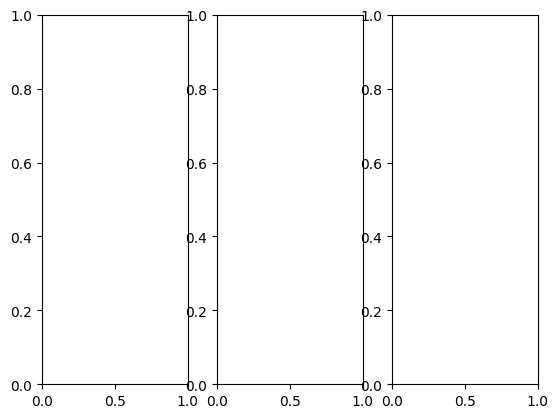

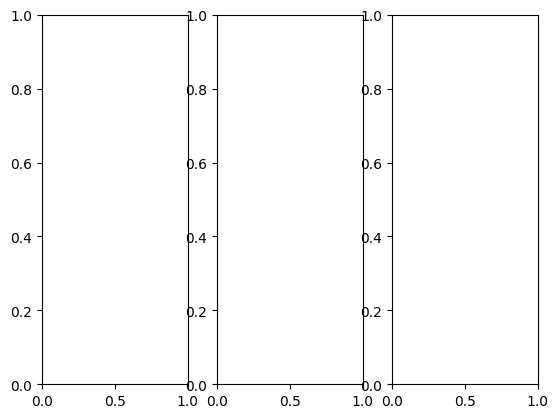

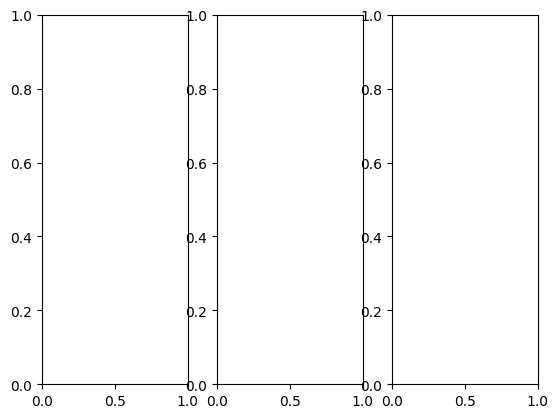

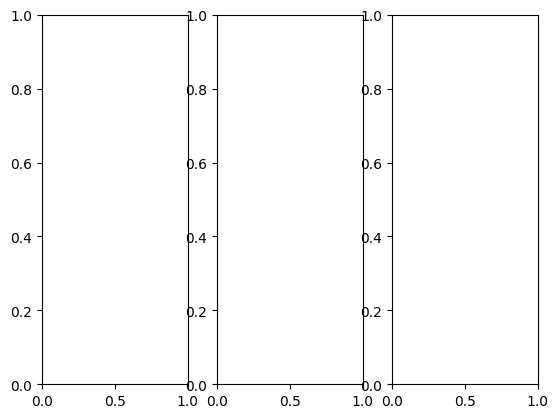

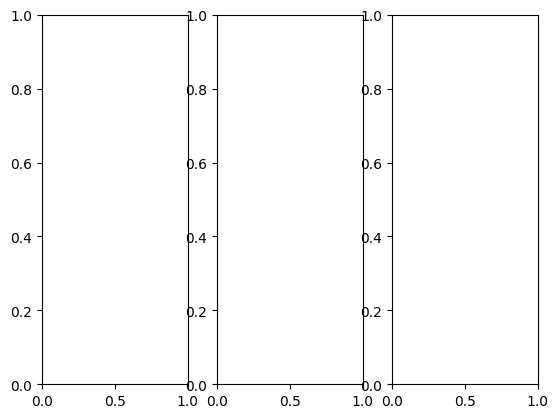

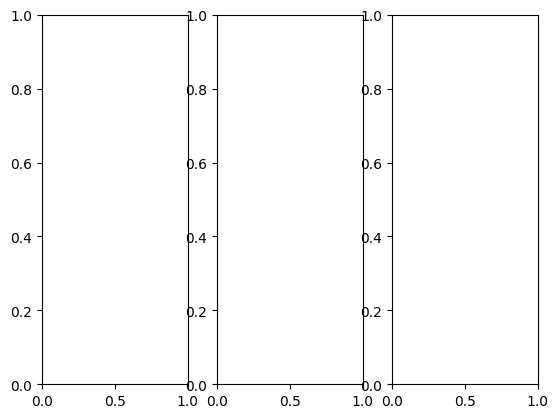

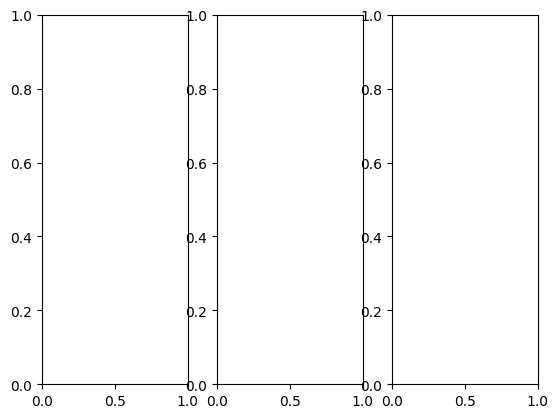

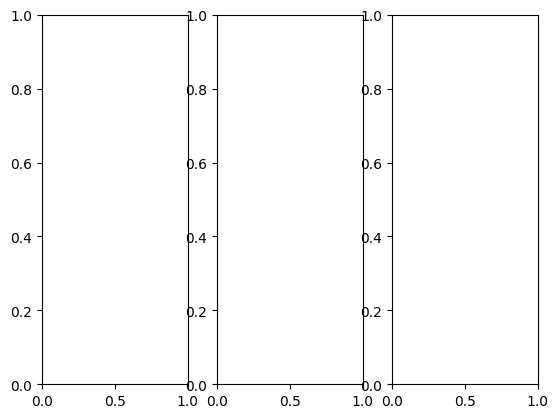

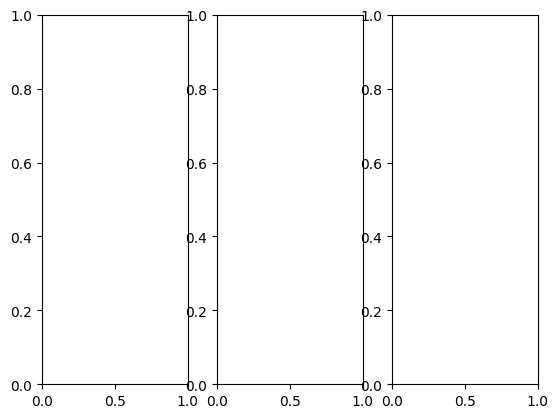

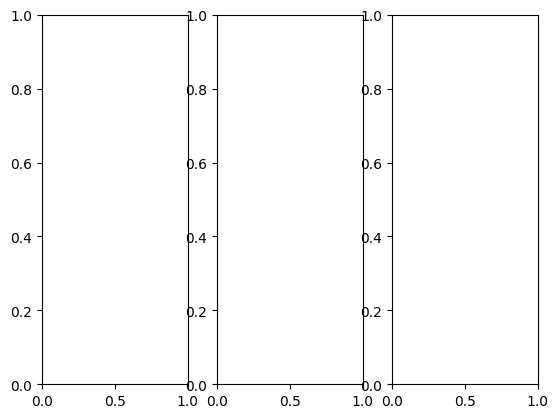

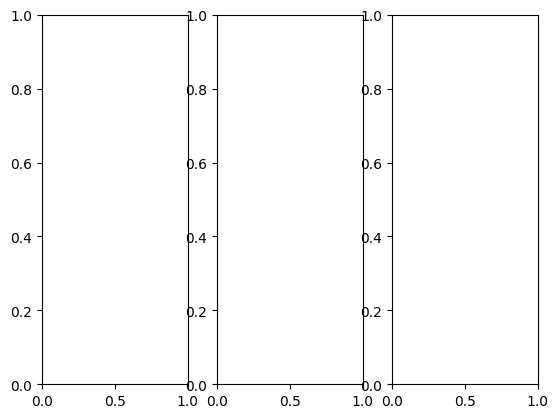

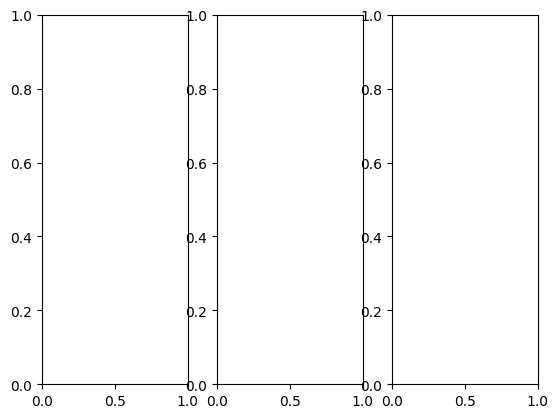

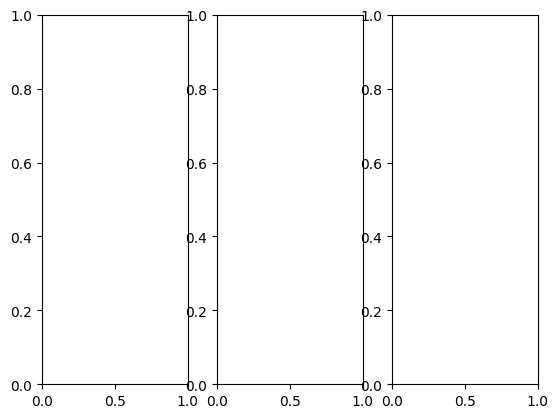

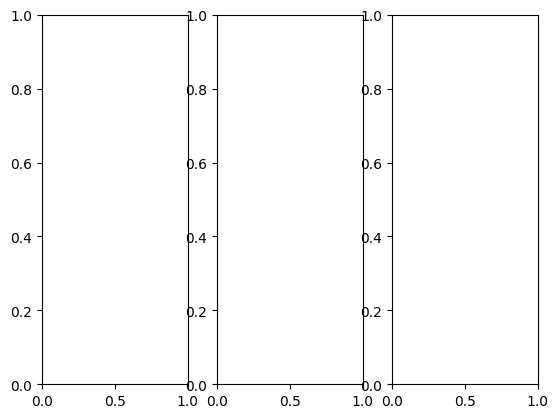

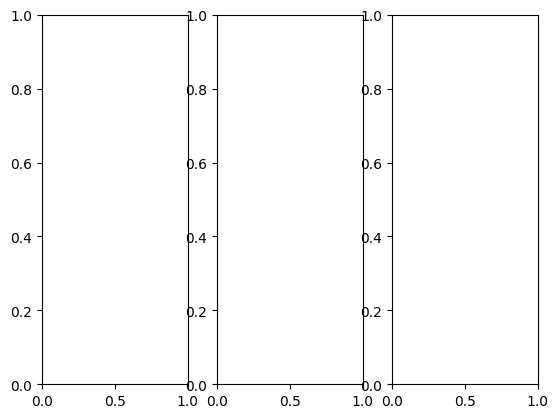

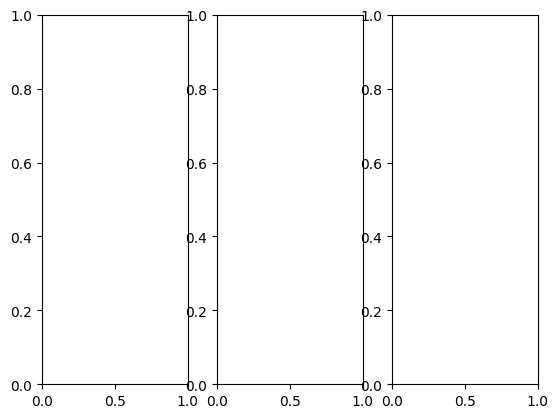

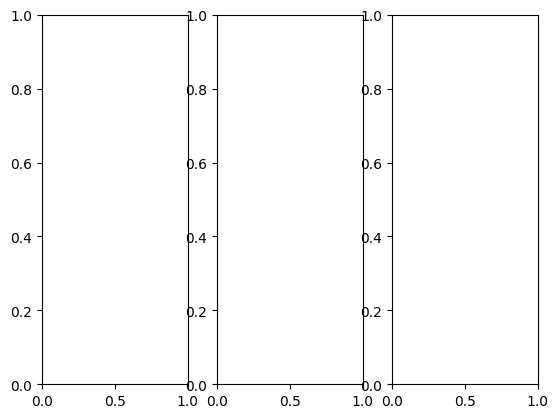

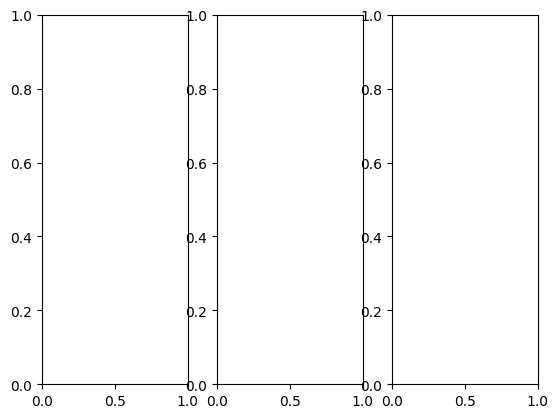

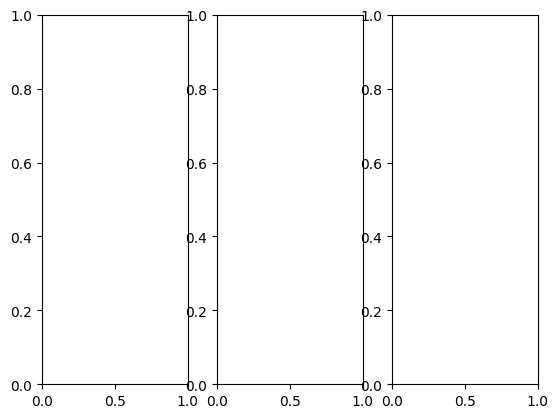

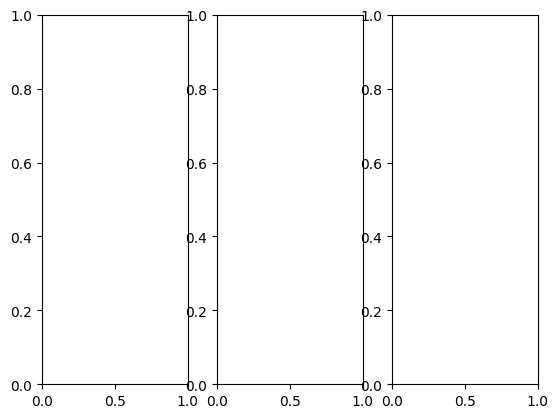

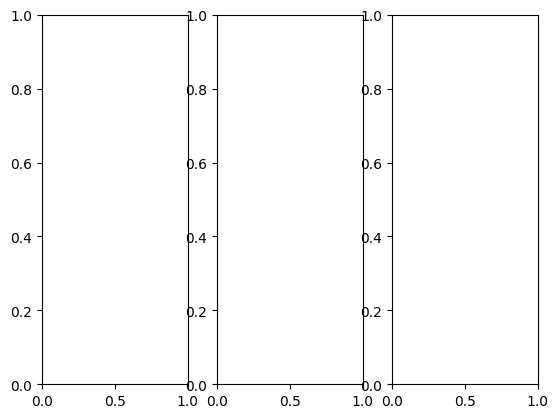

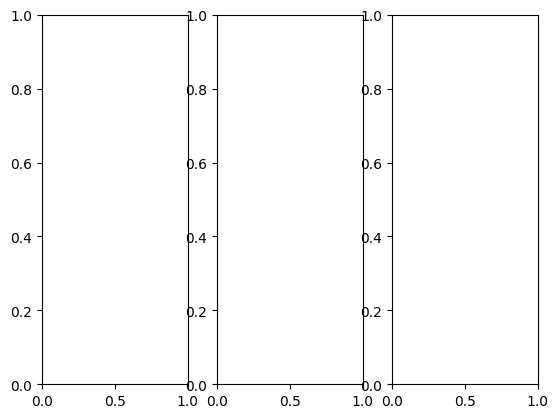

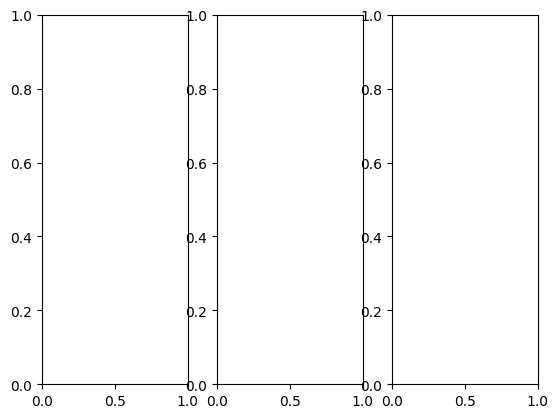

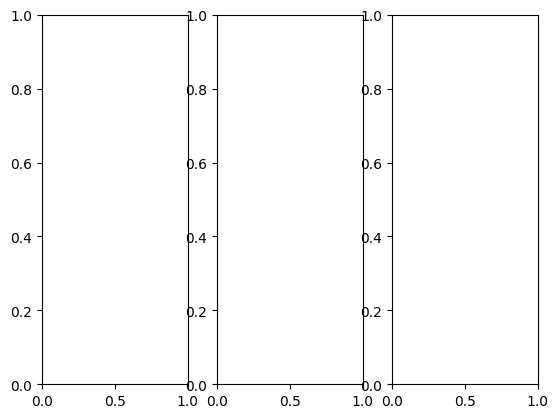

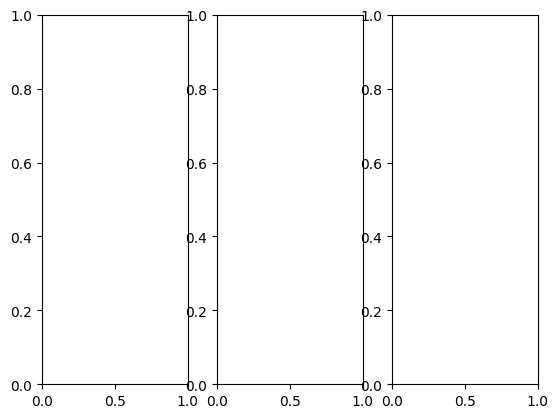

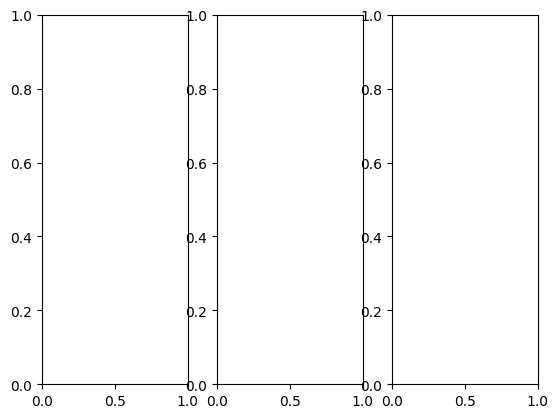

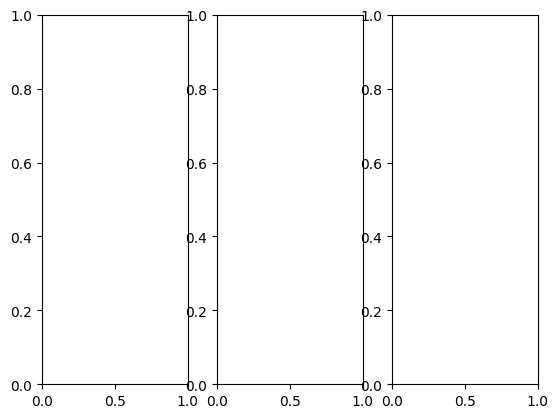

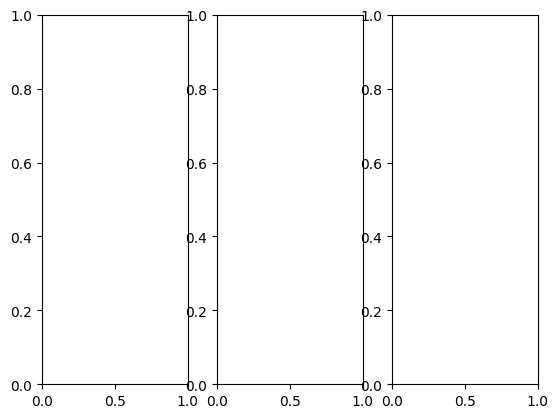

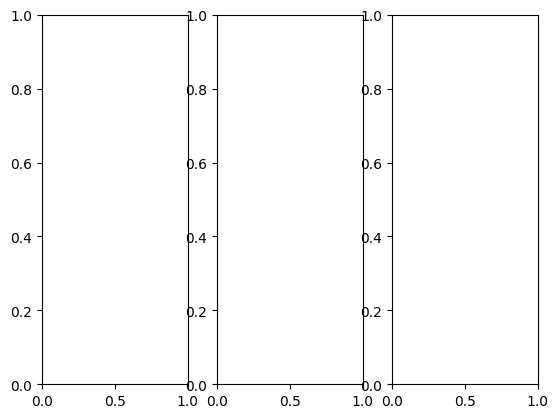

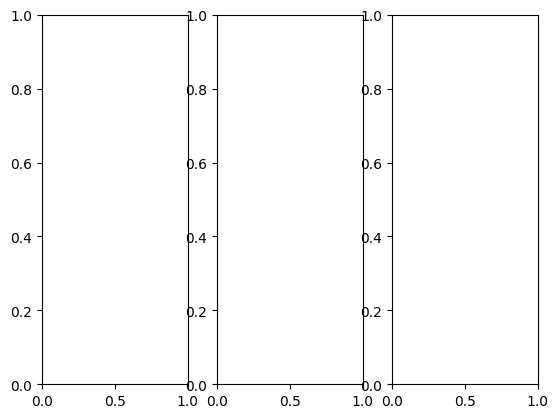

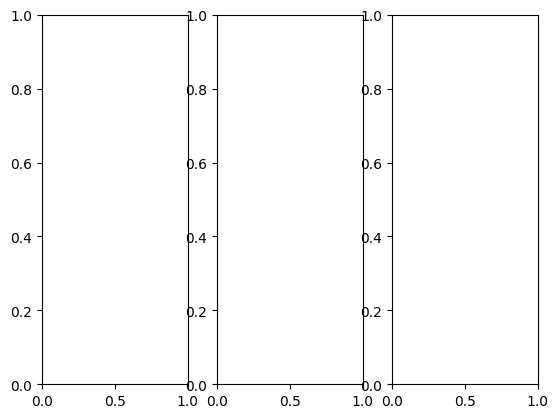

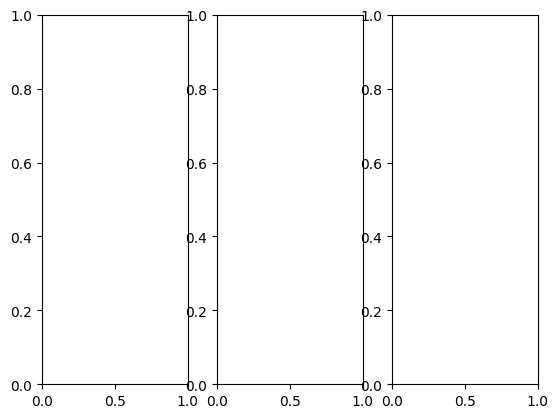

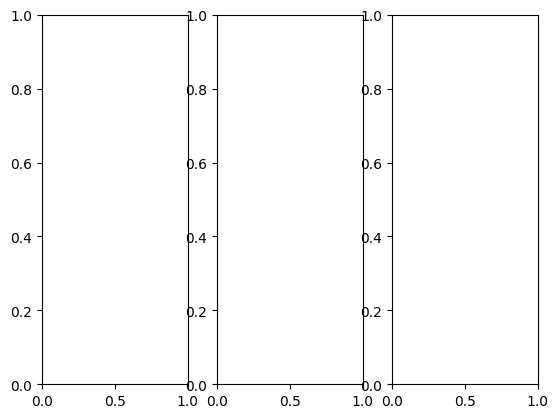

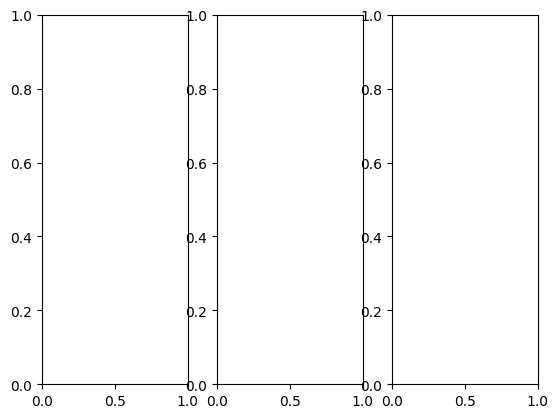

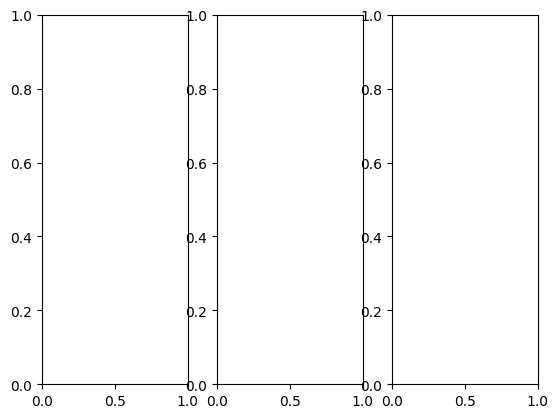

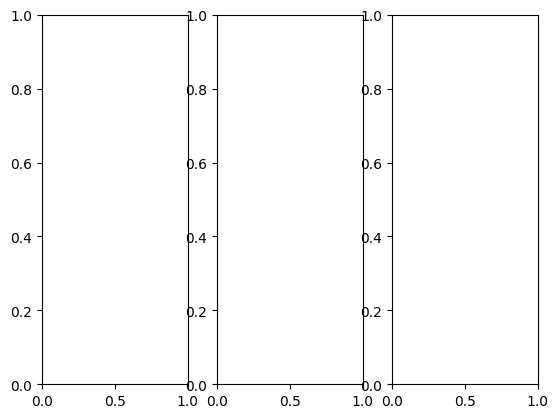

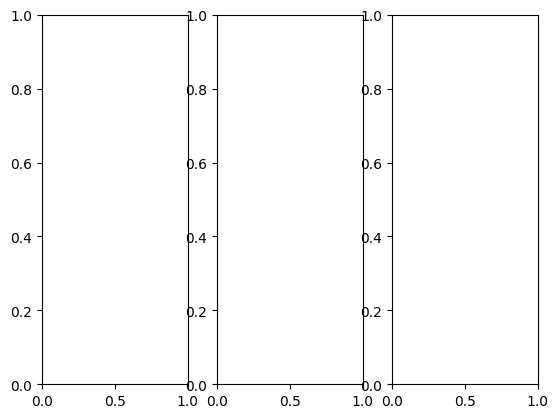

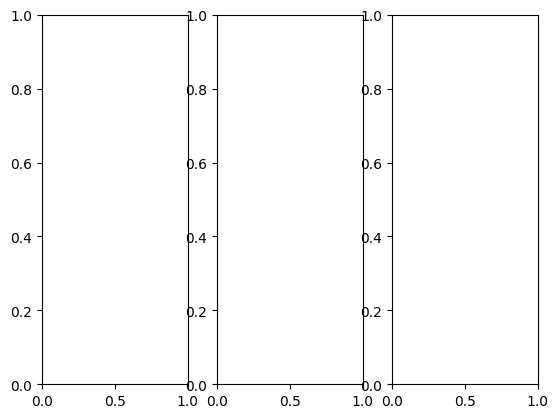

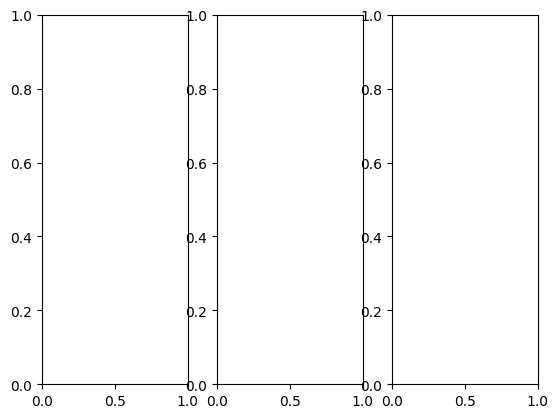

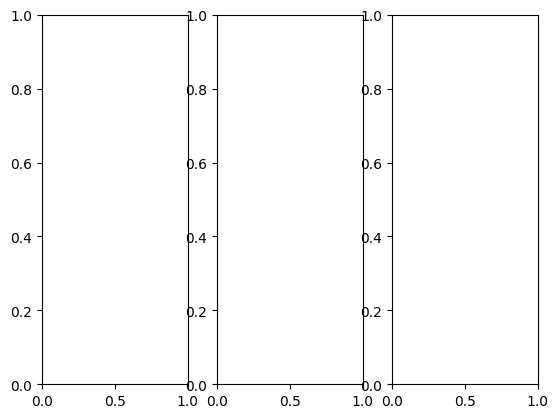

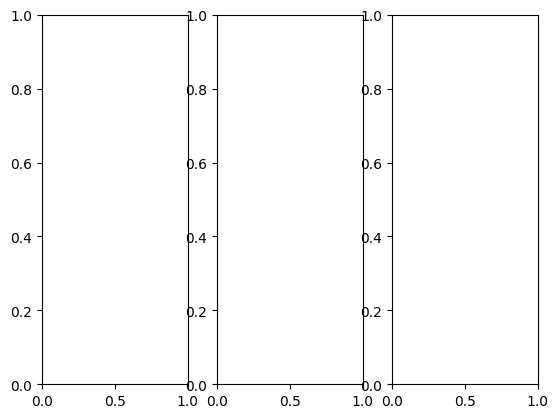

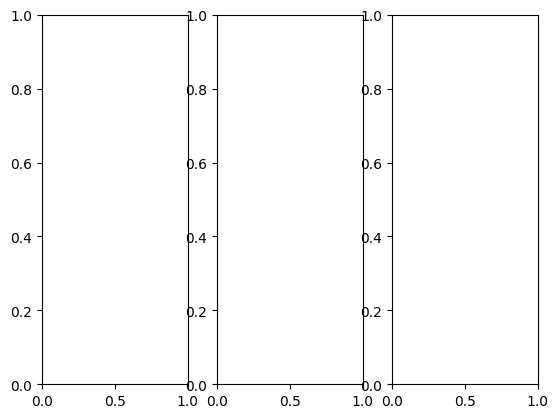

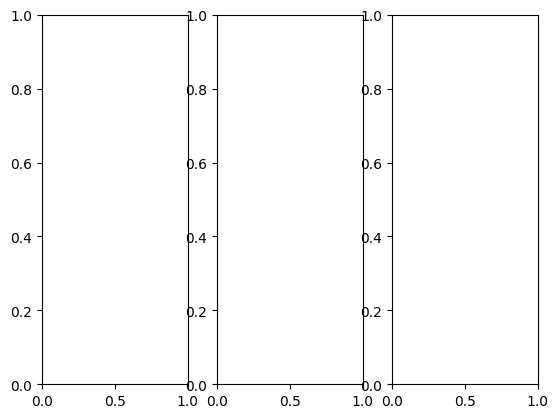

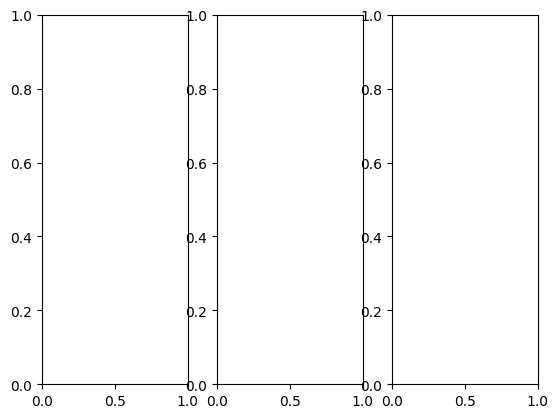

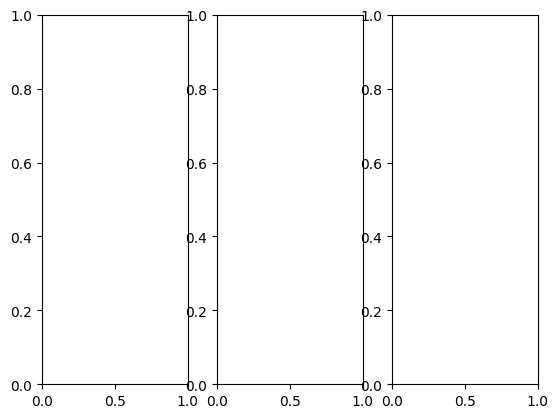

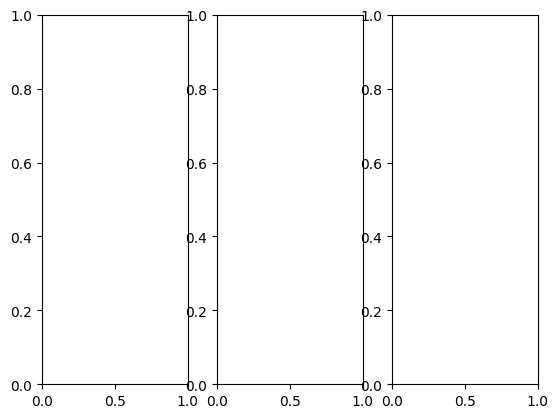

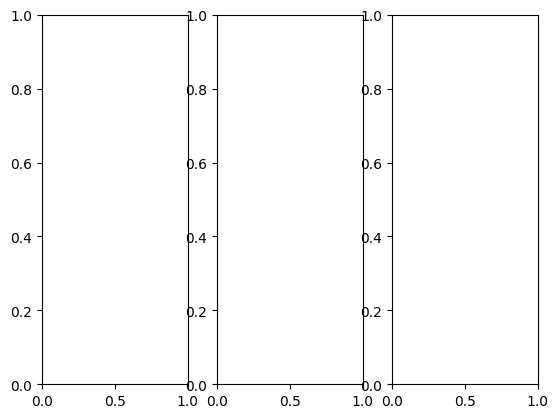

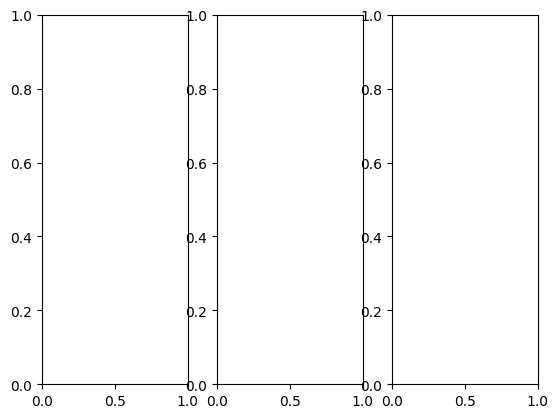

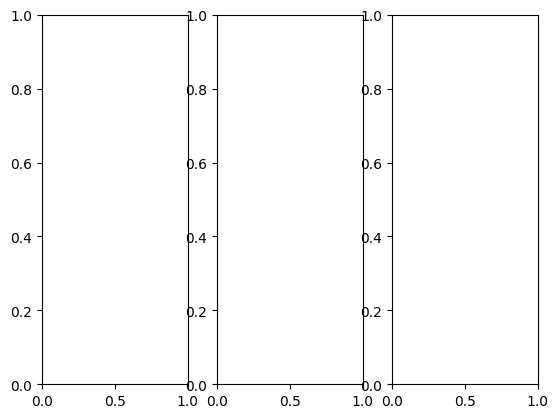

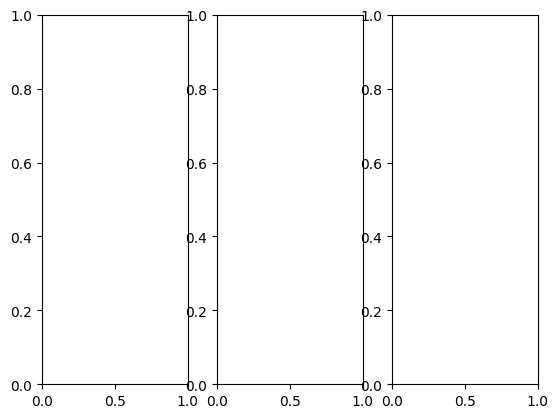

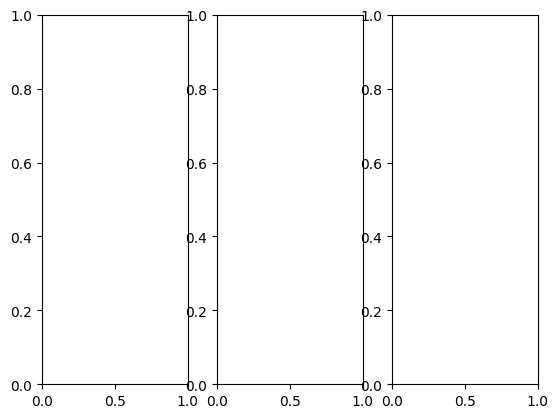

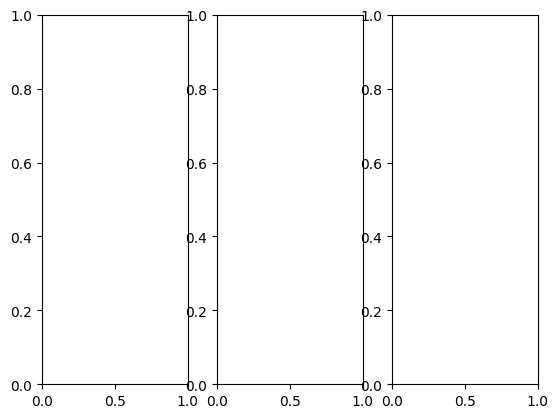

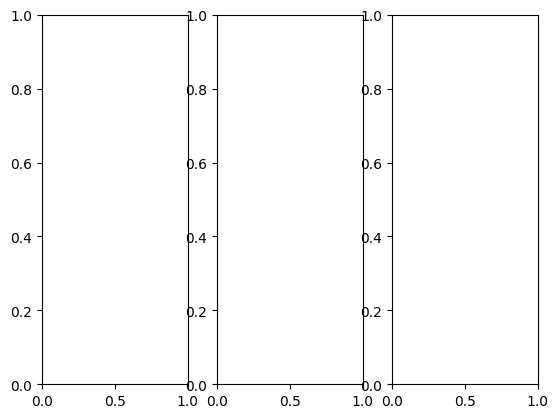

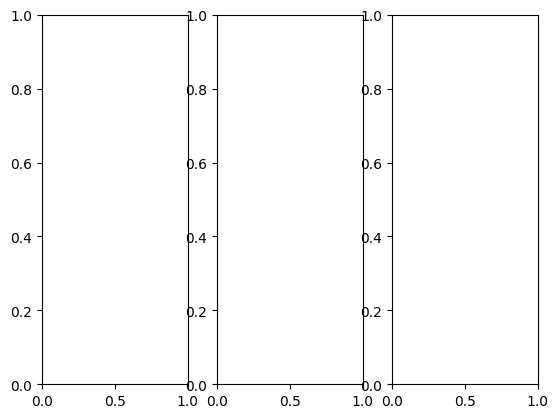

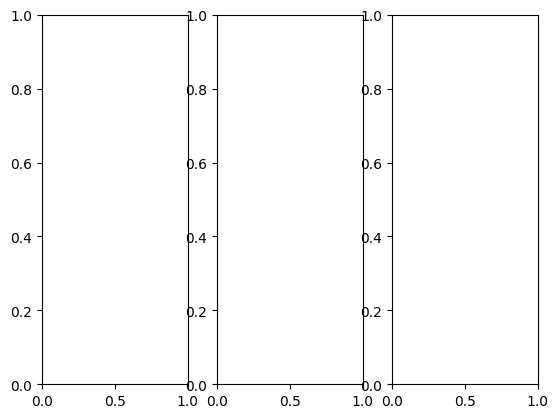

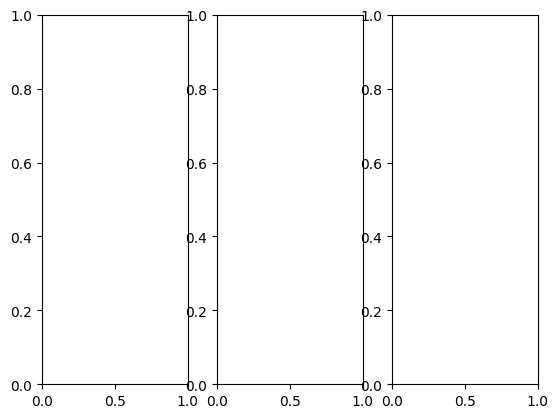

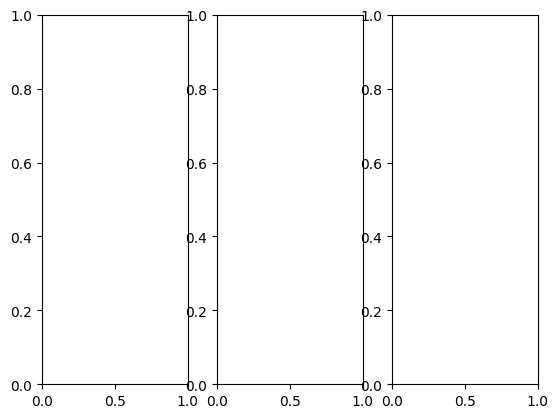

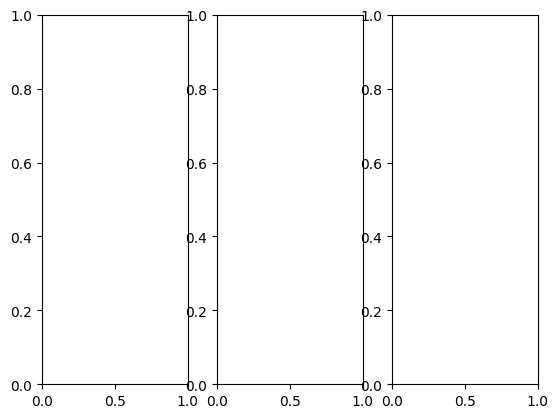

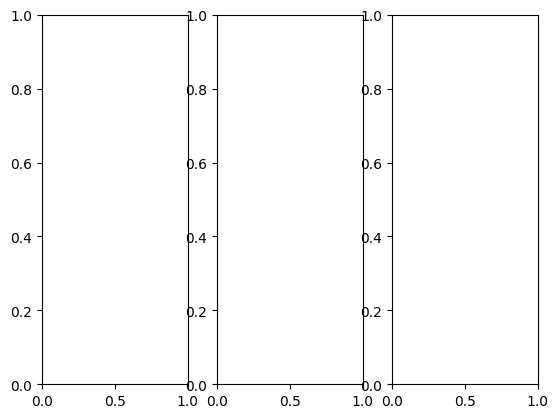

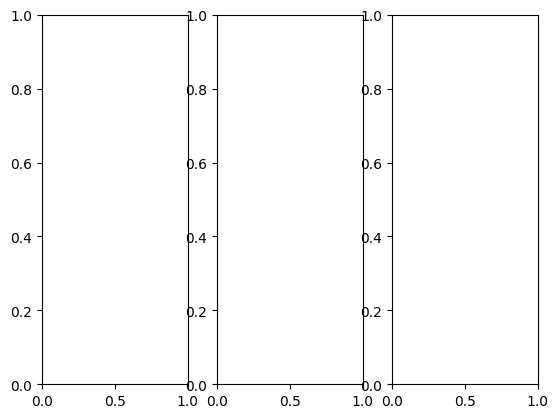

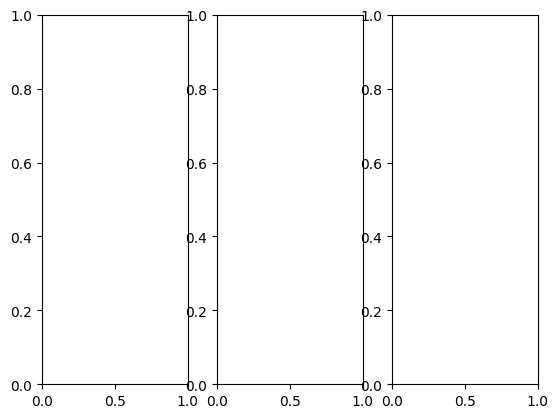

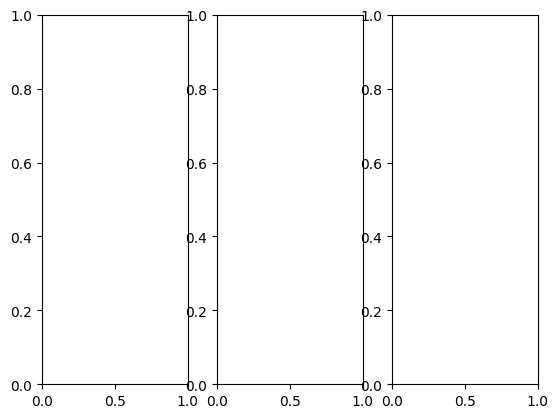

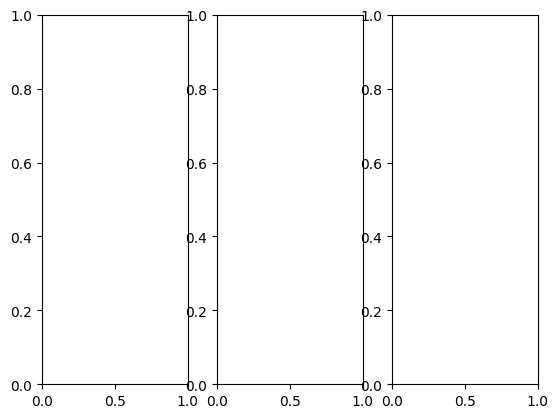

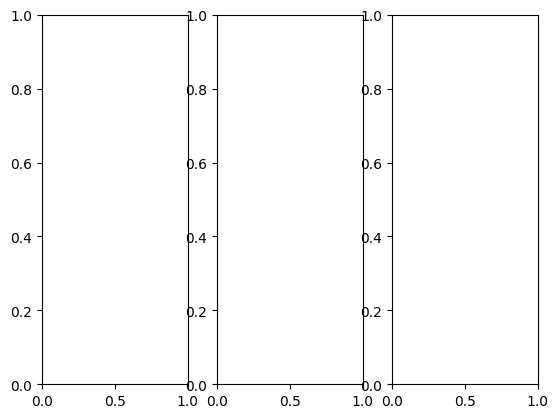

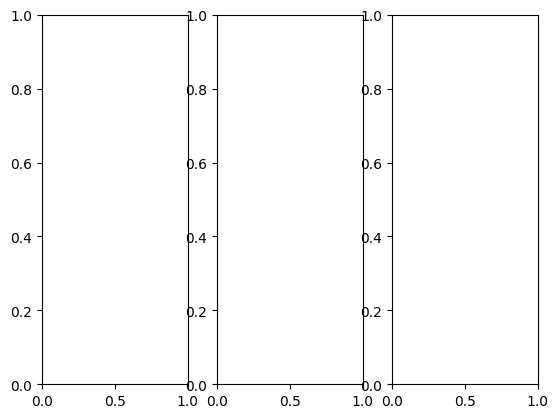

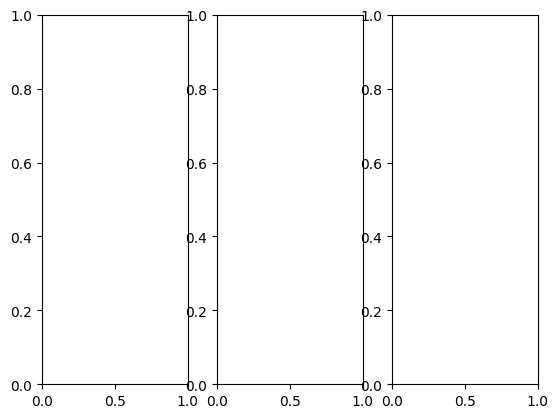

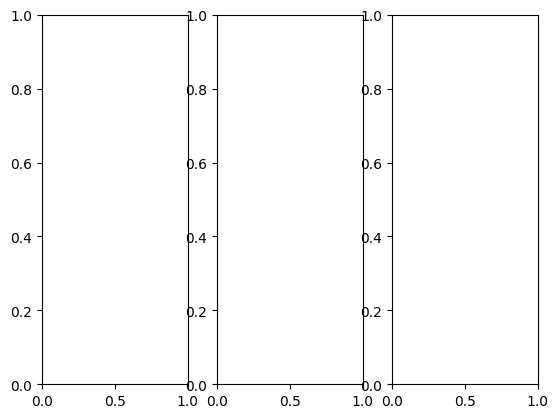

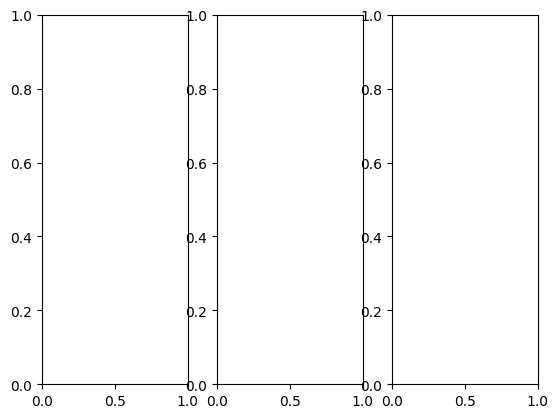

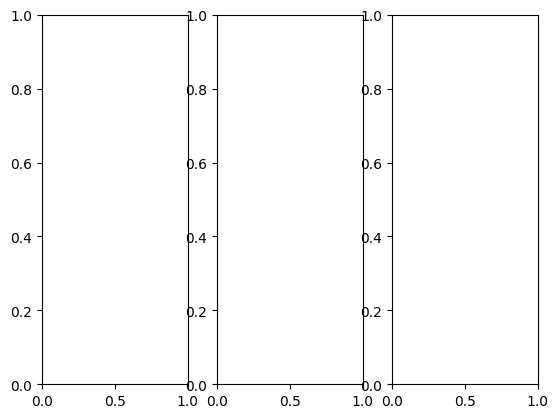

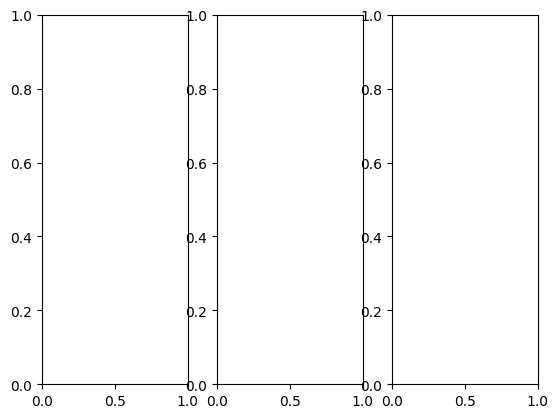

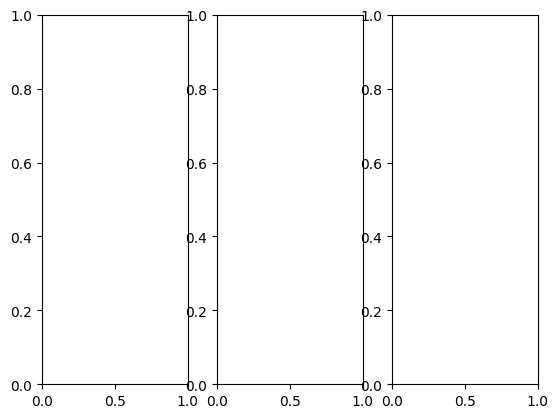

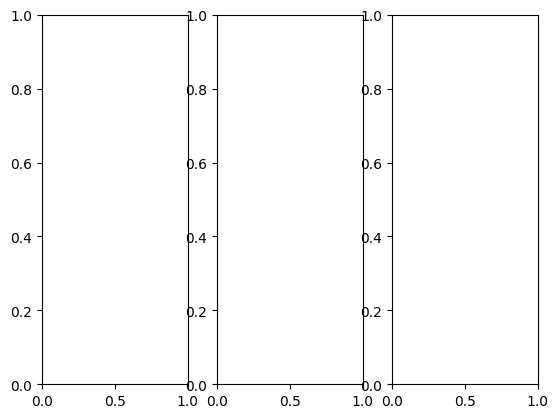

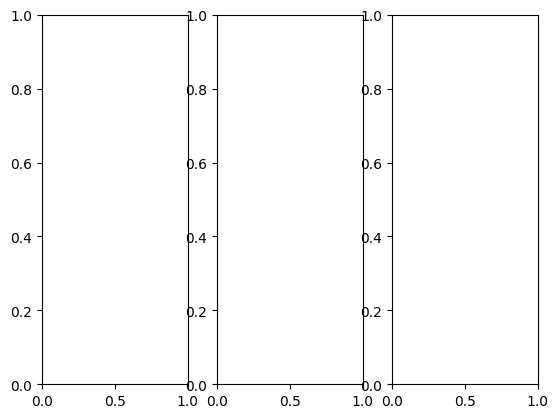

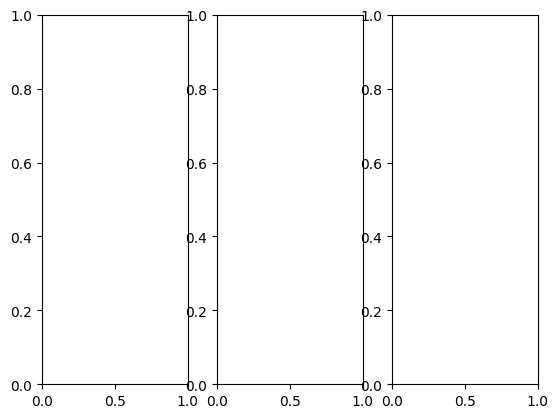

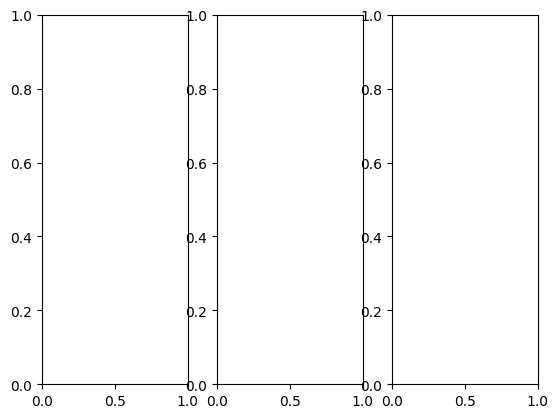

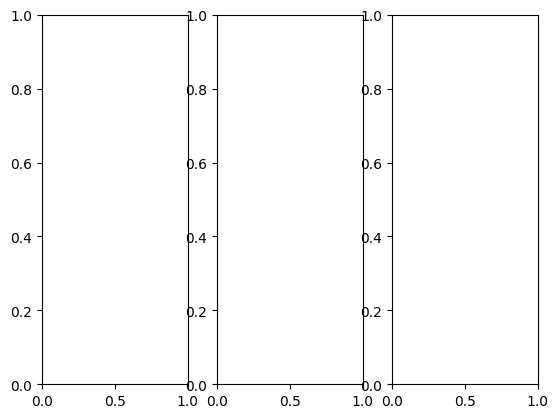

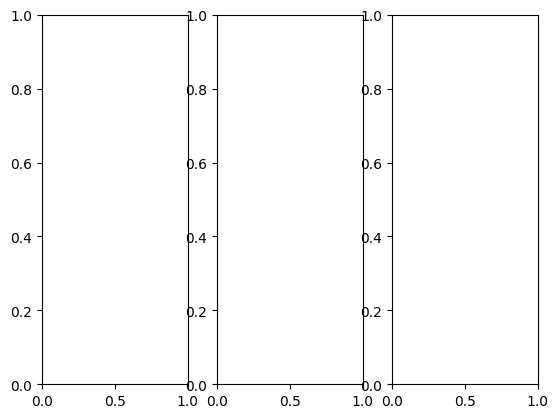

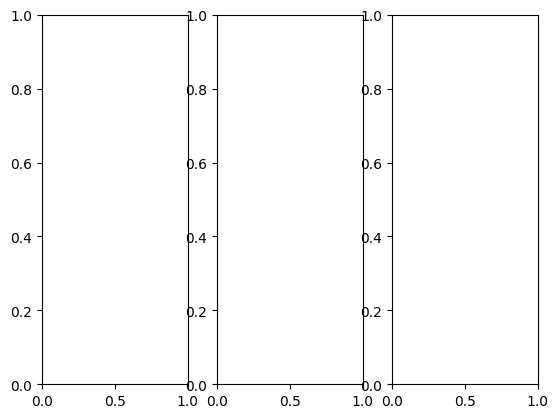

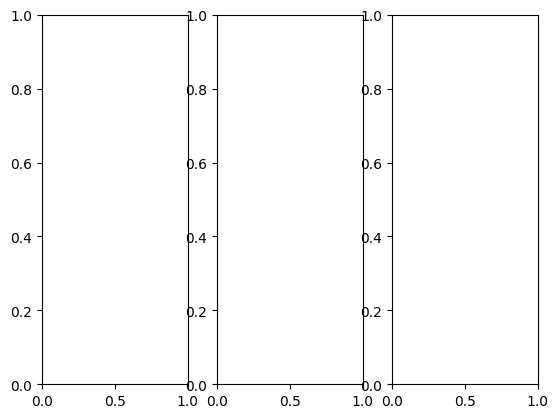

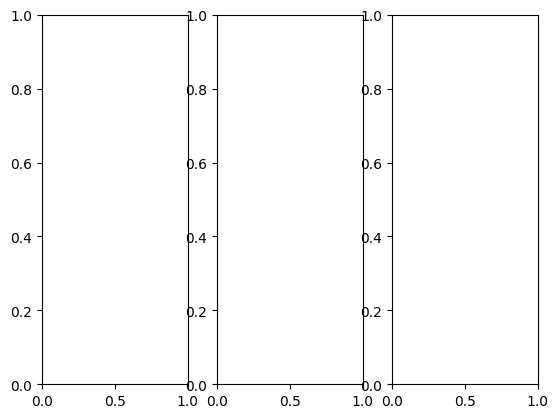

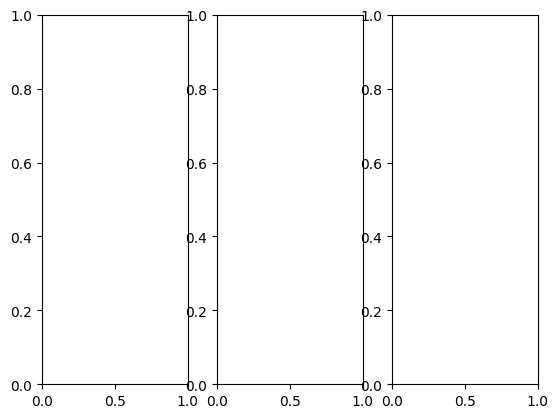

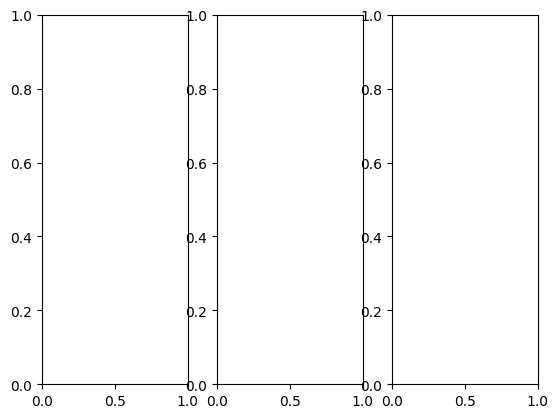

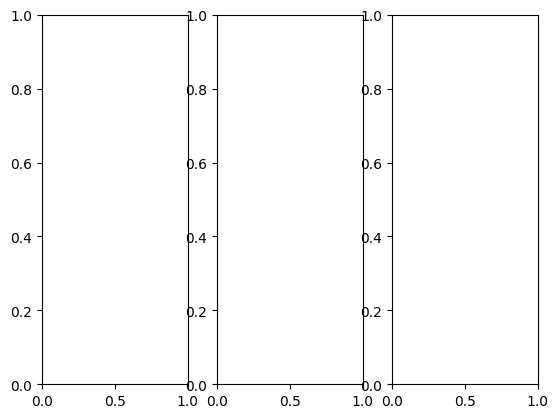

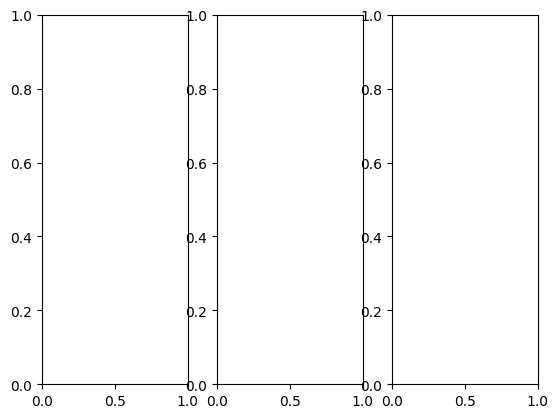

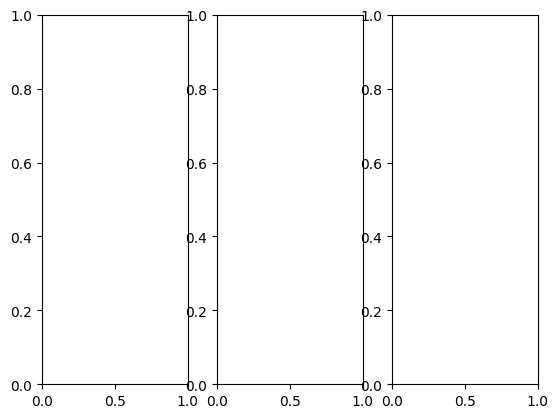

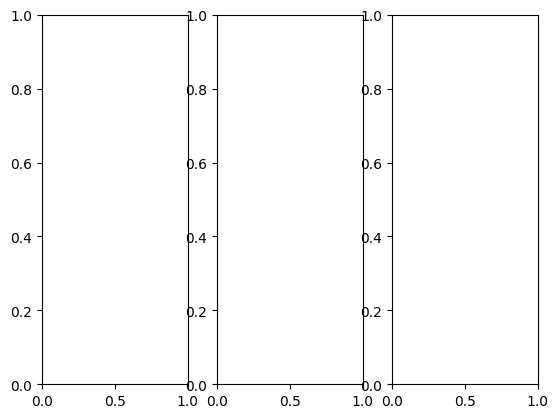

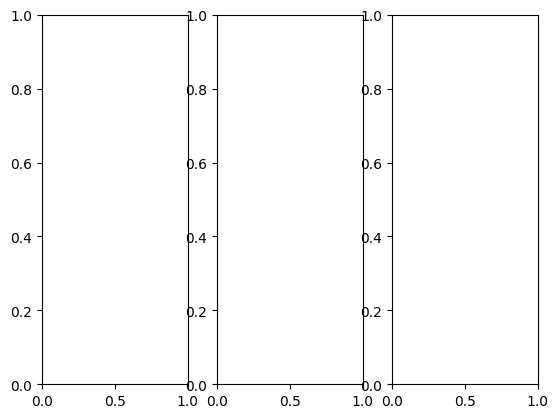

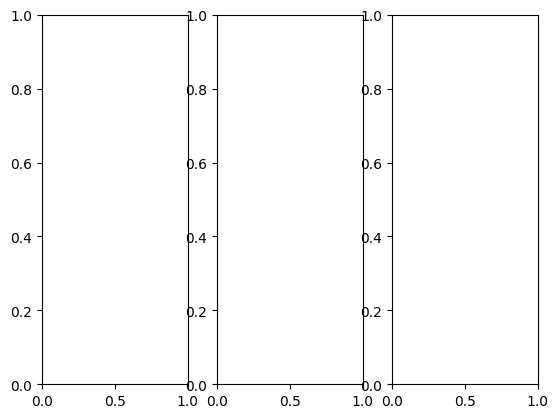

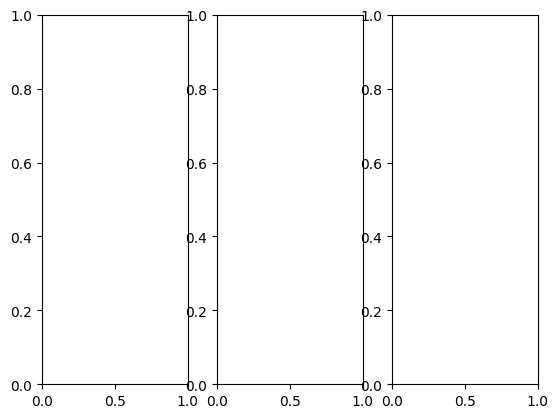

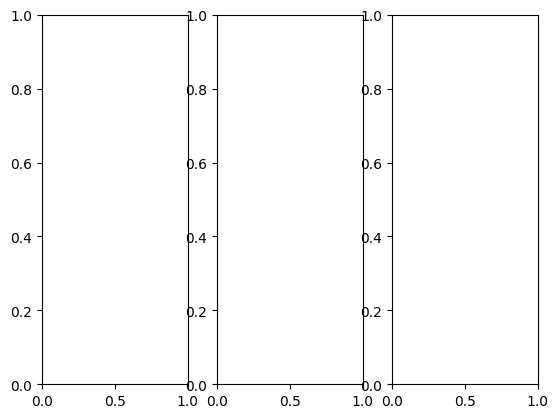

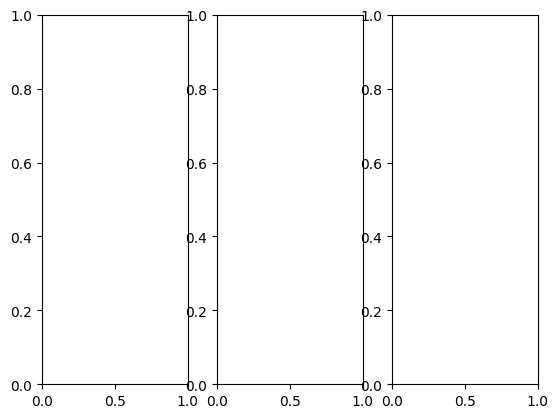

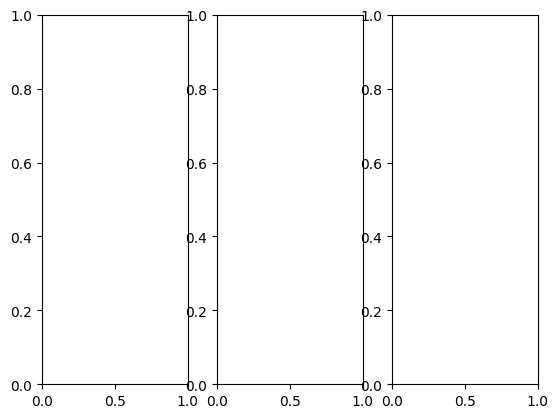

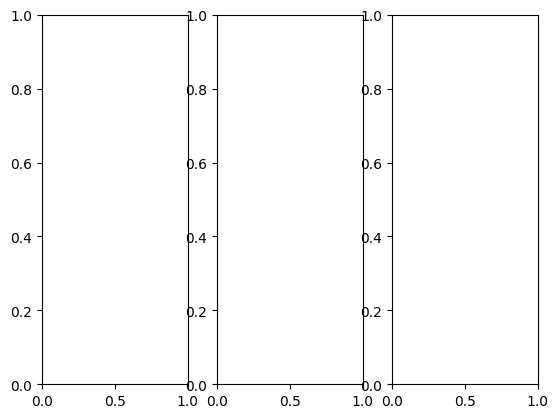

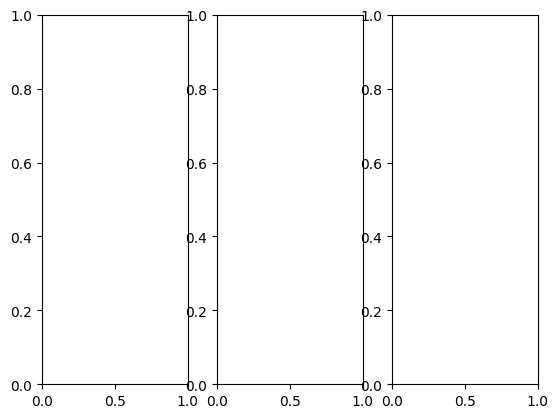

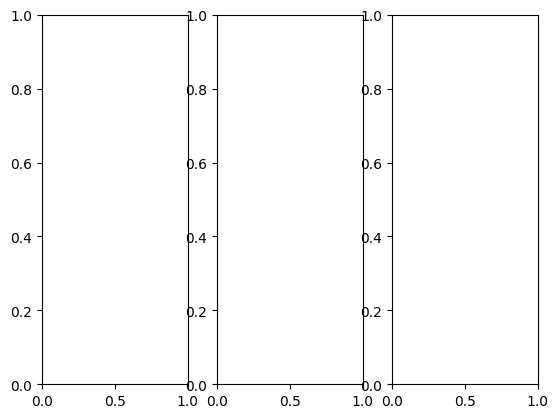

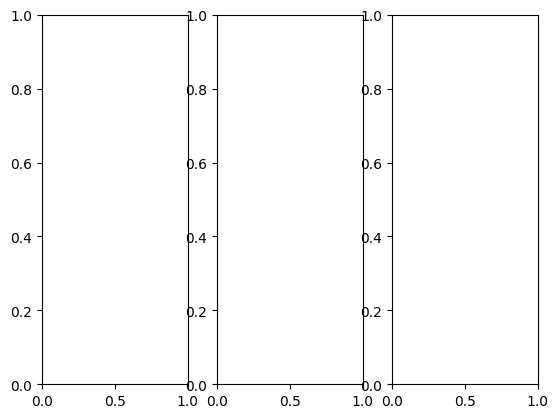

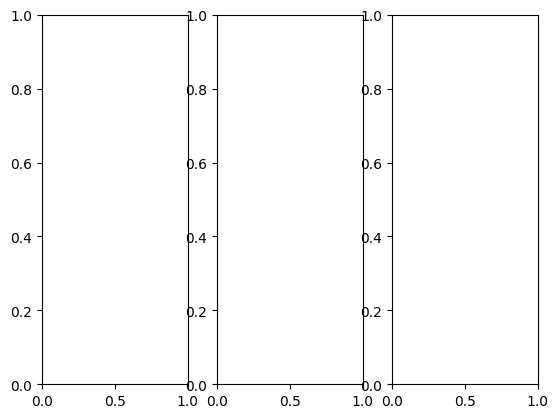

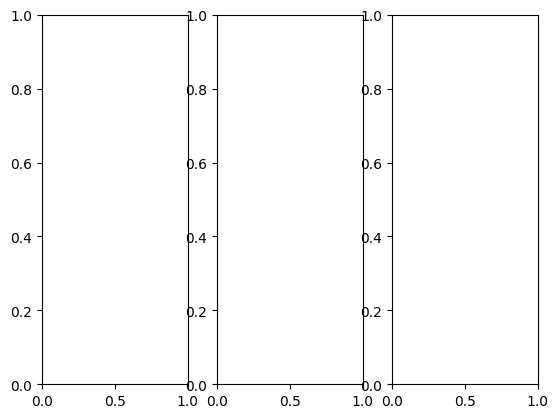

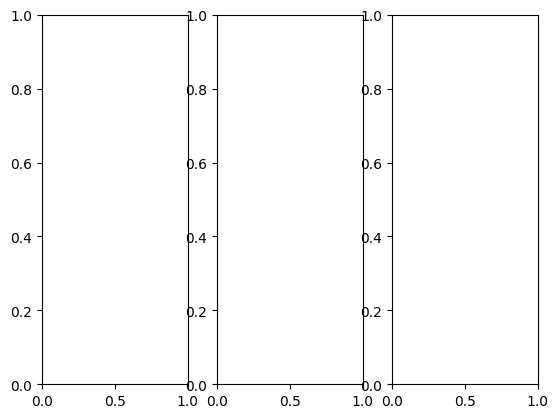

In [19]:
for i, (cam_type, rep) in enumerate(product(cam_types, range(repeats))):

  print(f"Running {get_task_name(task)} with {cam_type} and 1 demo, repeat: {rep}")

  agent = Agent(
    env.action_shape[0],
    PolicyType.SIMPLE_GRASP,
    cam_type,
    # grasp_thresh = 0.5, this is default
  ) 

  max_eplen = 250 if cam_type == CamType.WRIST else "demo_max"

  rets, done = run_grasp_with_agent(
    env, task, agent, demos, max_eplen = max_eplen, ## TODO: try 'demo_max'?? 

    training_params=training_params, 
    task_params=task_params,
    
    print_index=i
  )

  df.loc[i] = {
    "task_name": get_task_name(task),
    "cam_type": cam_type,
    "demo_count": 1,
    "max_eplen": max_eplen,
    "is_success": done,
    "min_distance": min(rets["distances"]),
    "final_distance": rets["distances"][-1],
    "gripper_image_paths": rets["gripper_image_paths"]

  }
  df.to_csv("vision_single_static-results,csv", index=True)

